In [1]:
import mlflow
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from experiment_config import TRAINGING_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.model.experiment_utils import *
from src.model.model_utils import *
from src.model.models import MLPWithDropout, MLPWithDropoutBN

In [2]:
features_path = f"{TRAINGING_CONFIG['features_path']}/all_combined_features_2017-24.csv"
output_dir = f"{REPO_PATH}/models/ml_models"

In [3]:
seasons=sorted(TRAINGING_CONFIG['seasons'])
target_dfs=[pd.read_csv(f"{TRAINGING_CONFIG['processed_data_path']}/{season}/all_target_df.csv") for season in seasons[1:]]
for df in target_dfs:
    df['date']= pd.to_datetime(df['date'])
target_df = pd.concat(target_dfs, ignore_index=True)
target_columns=target_df.drop(columns=TRAINGING_CONFIG['key_columns']).columns.tolist()

In [4]:
feature_df = pd.read_csv(features_path)
feature_df['date']= pd.to_datetime(feature_df['date'])
feature_df, target_df=align_on_keys(feature_df, target_df, TRAINGING_CONFIG['key_columns'])

In [5]:
param_grid = {
    'model_params.hidden_layers': [(64, 32, 32), (128, 128, 64, 64), (128,64), (128, 128, 64)],
    'model_params.activation': ['relu'],
    'model_params.dropout_rate': [0.1, 0.5],
    'learning_rate': [0.0001, 0.00001],
    'batch_size': [64, 128],
    'epochs': [1000],
    'l2_reg': [0.1, 0]
}


In [6]:
feature_df.fillna(-1, inplace=True)

Training MLPwithDropoutBN on home_goals with param grid: {'model_params.hidden_layers': [(64, 32, 32), (128, 128, 64, 64), (128, 64), (128, 128, 64)], 'model_params.activation': ['relu'], 'model_params.dropout_rate': [0.1, 0.5], 'learning_rate': [0.0001, 1e-05], 'batch_size': [64, 128], 'epochs': [1000], 'l2_reg': [0.1, 0]}
Using range-based class conversion with range: (0, 5)
Sampling 10 parameter sets from 64 total combinations
Training fold 1/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 10. Best loss was at epoch 5


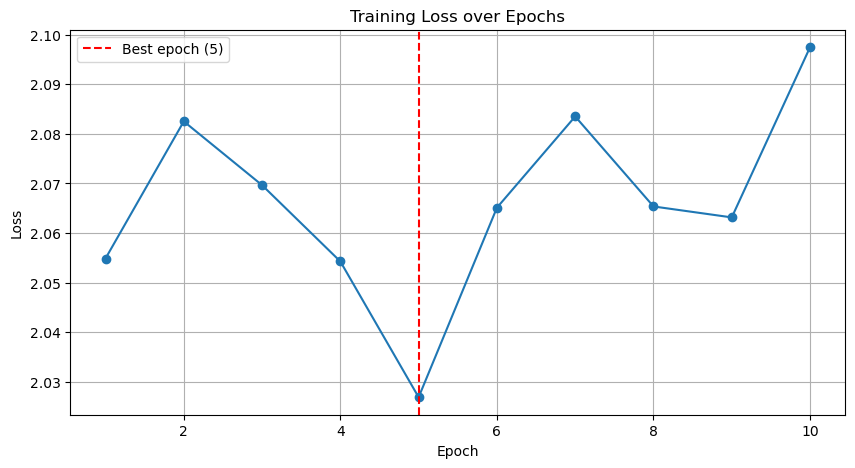

Best loss: 2.026869 at epoch 5
Final loss: 2.097493
Training fold 2/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 7. Best loss was at epoch 2


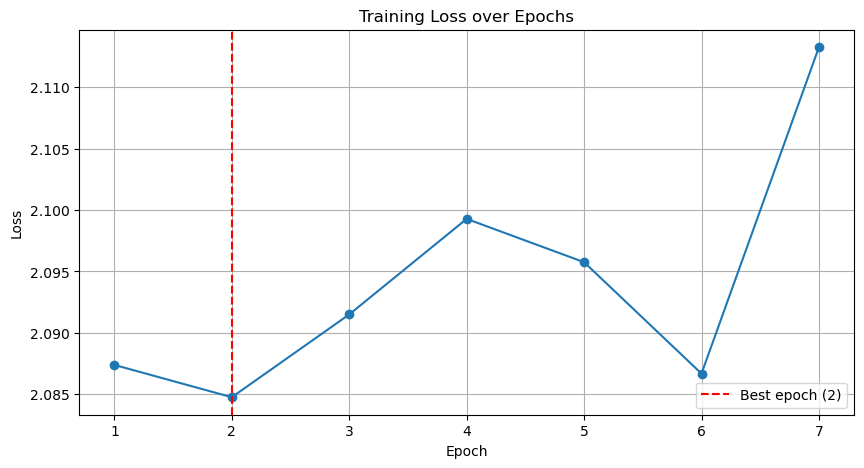

Best loss: 2.084763 at epoch 2
Final loss: 2.113242
Training fold 3/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 19. Best loss was at epoch 14


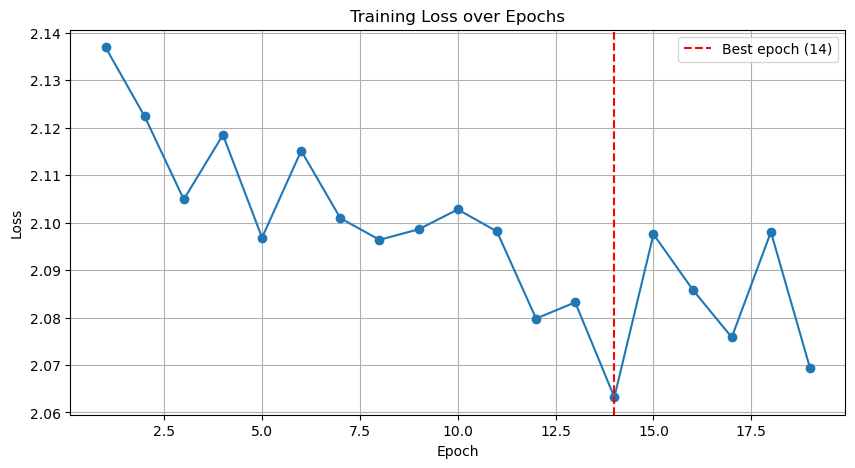

Best loss: 2.063211 at epoch 14
Final loss: 2.069337
Training fold 4/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 35. Best loss was at epoch 30


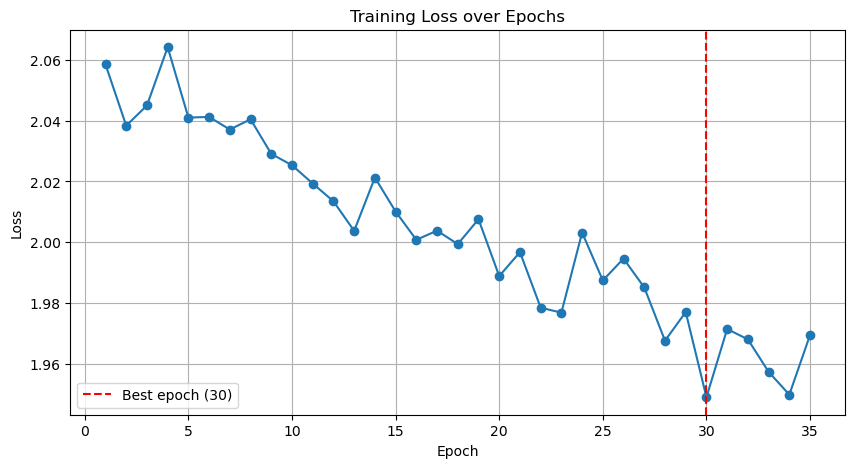

Best loss: 1.948963 at epoch 30
Final loss: 1.969449
Training fold 5/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 24. Best loss was at epoch 19


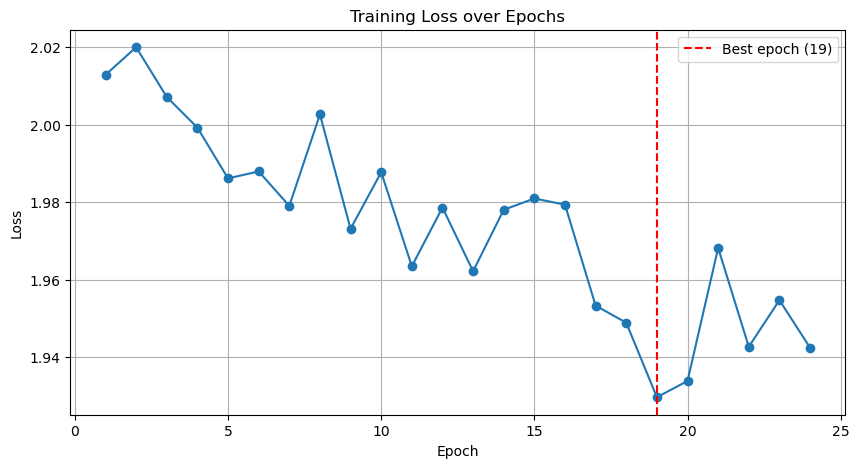

Best loss: 1.929646 at epoch 19
Final loss: 1.942429
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 59. Best loss was at epoch 54


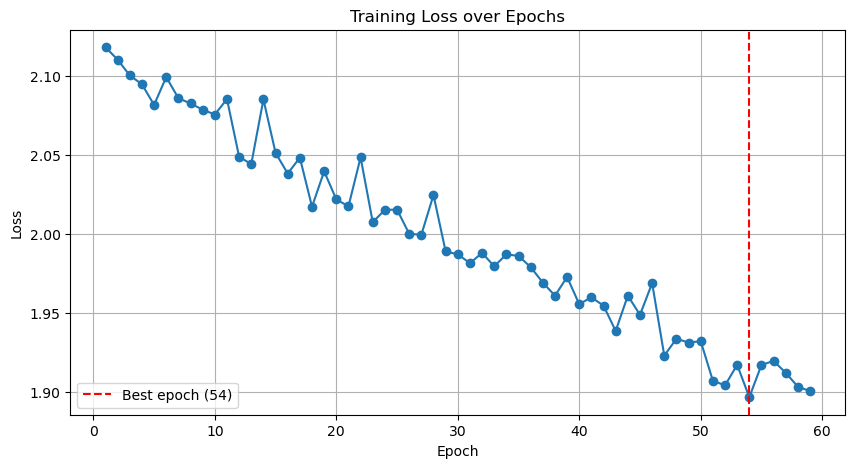

Best loss: 1.896448 at epoch 54
Final loss: 1.900323
{'home_goals_train_accuracy': 0.17507101086048454, 'home_goals_train_precision': 0.17945110684545995, 'home_goals_valid_accuracy': 0.16390977443609023, 'home_goals_valid_precision': 0.12758627837210218, 'home_goals_test_accuracy': 0.2593984962406015, 'home_goals_test_precision': 0.1137172198789657, 'home_goals_train_lte_0_accuracy': 0.7007518796992481, 'home_goals_train_lte_0_accuracy_std': 0.058896709857341745, 'home_goals_train_lte_0_precision': 0.2675362284664393, 'home_goals_train_lte_0_precision_std': 0.15001705437731583, 'home_goals_train_eq_1_accuracy': 0.6742522974101921, 'home_goals_train_eq_1_accuracy_std': 0.018161264843088956, 'home_goals_train_eq_1_precision': 0.5586970324196489, 'home_goals_train_eq_1_precision_std': 0.2357797806104568, 'home_goals_train_eq_2_accuracy': 0.6140267335004177, 'home_goals_train_eq_2_accuracy_std': 0.13334723118168404, 'home_goals_train_eq_2_precision': 0.2056692795714458, 'home_goals_train_

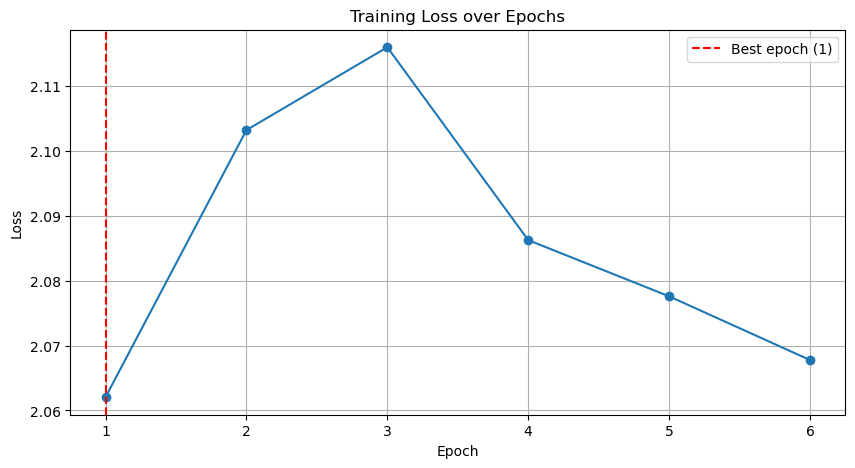

Best loss: 2.062042 at epoch 1
Final loss: 2.067767
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 8. Best loss was at epoch 3


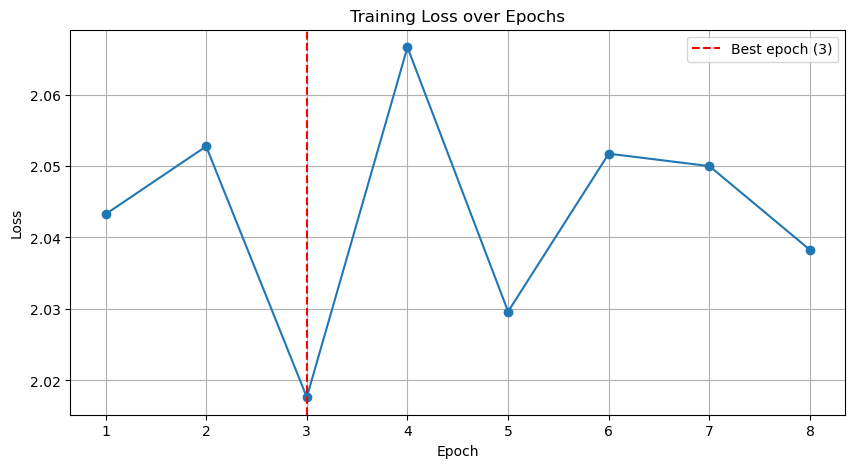

Best loss: 2.017650 at epoch 3
Final loss: 2.038254
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 10. Best loss was at epoch 5


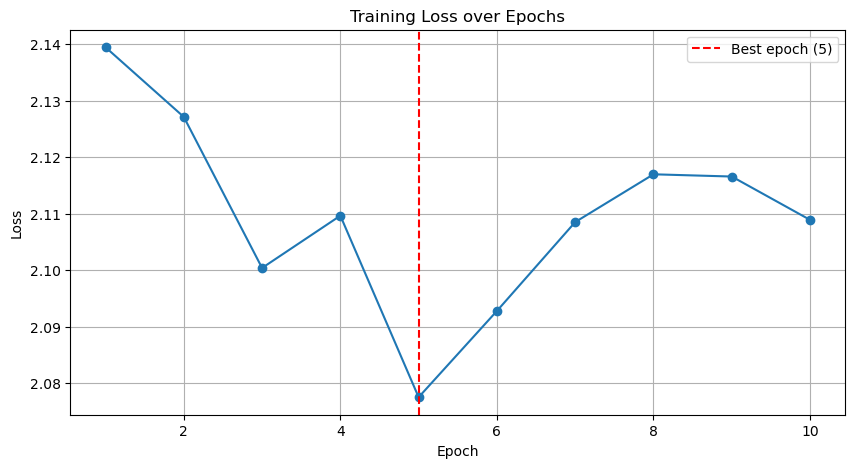

Best loss: 2.077542 at epoch 5
Final loss: 2.108900
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 13. Best loss was at epoch 8


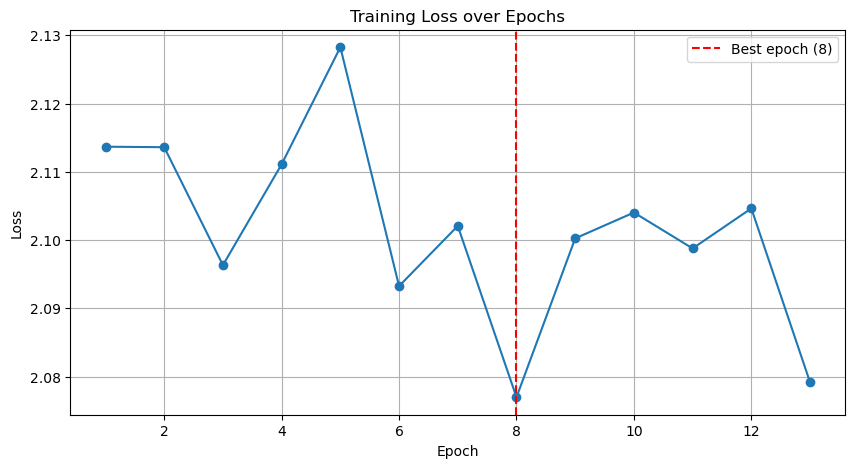

Best loss: 2.076976 at epoch 8
Final loss: 2.079168
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 20. Best loss was at epoch 15


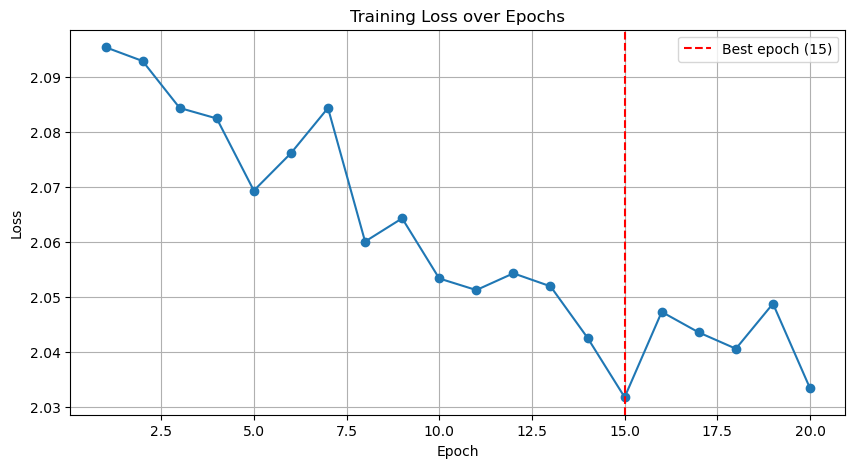

Best loss: 2.031821 at epoch 15
Final loss: 2.033434
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 30. Best loss was at epoch 25


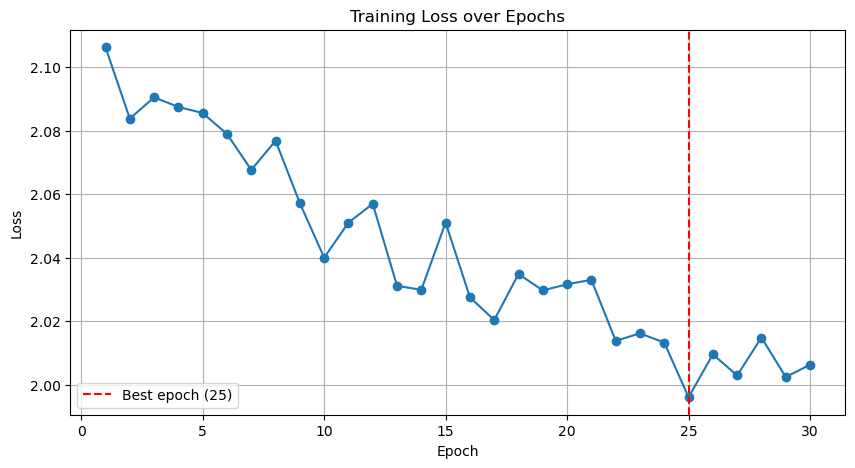

Best loss: 1.996082 at epoch 25
Final loss: 2.006317
{'home_goals_train_accuracy': 0.1315204678362573, 'home_goals_train_precision': 0.14649001710079806, 'home_goals_valid_accuracy': 0.12531328320802007, 'home_goals_valid_precision': 0.10873366686455296, 'home_goals_test_accuracy': 0.24060150375939848, 'home_goals_test_precision': 0.2445405929726487, 'home_goals_train_lte_0_accuracy': 0.6381787802840434, 'home_goals_train_lte_0_accuracy_std': 0.20275990413301861, 'home_goals_train_lte_0_precision': 0.44170420075605277, 'home_goals_train_lte_0_precision_std': 0.2201702482954904, 'home_goals_train_eq_1_accuracy': 0.6490142021720969, 'home_goals_train_eq_1_accuracy_std': 0.05153027941771883, 'home_goals_train_eq_1_precision': 0.2906479948732603, 'home_goals_train_eq_1_precision_std': 0.14858659892451215, 'home_goals_train_eq_2_accuracy': 0.7358312447786132, 'home_goals_train_eq_2_accuracy_std': 0.03587673947457725, 'home_goals_train_eq_2_precision': 0.1569799218057502, 'home_goals_train_e

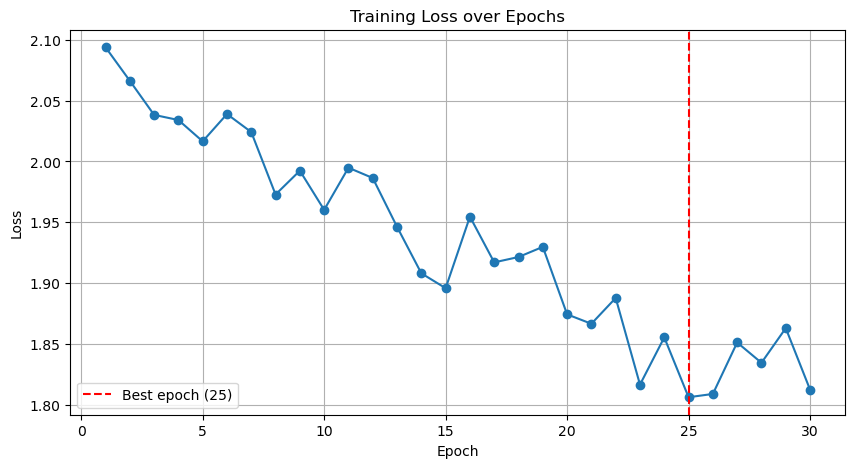

Best loss: 1.806298 at epoch 25
Final loss: 1.812529
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 117. Best loss was at epoch 112


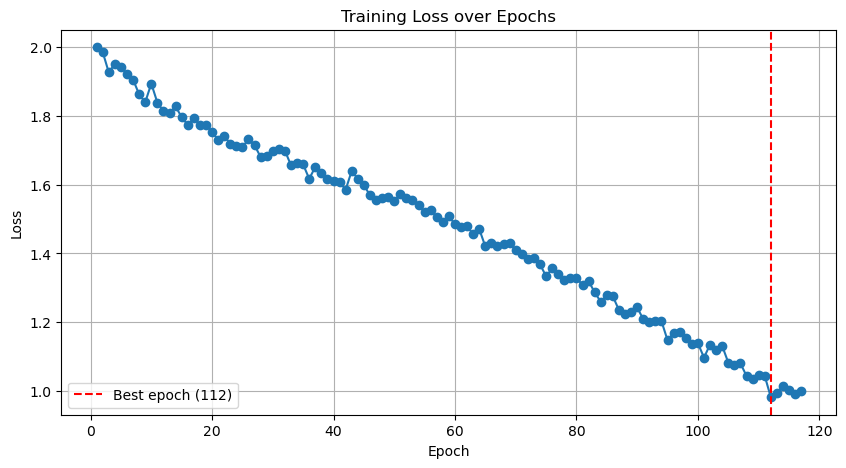

Best loss: 0.982488 at epoch 112
Final loss: 1.001871
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 43. Best loss was at epoch 38


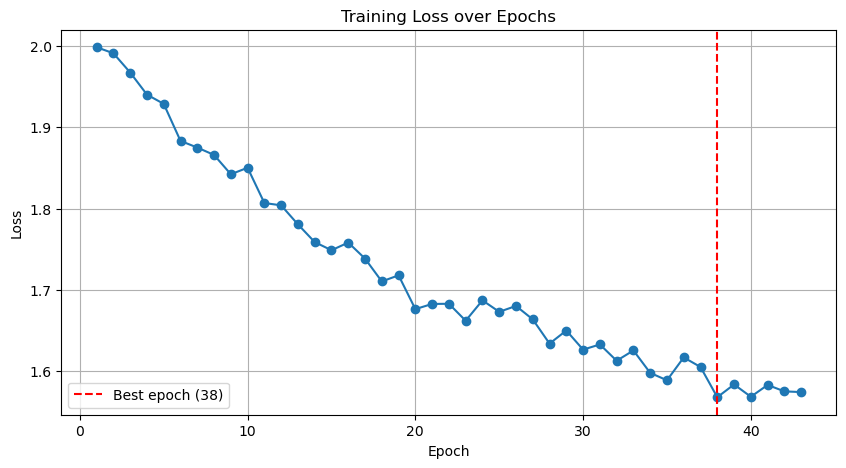

Best loss: 1.568235 at epoch 38
Final loss: 1.574548
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 173. Best loss was at epoch 168


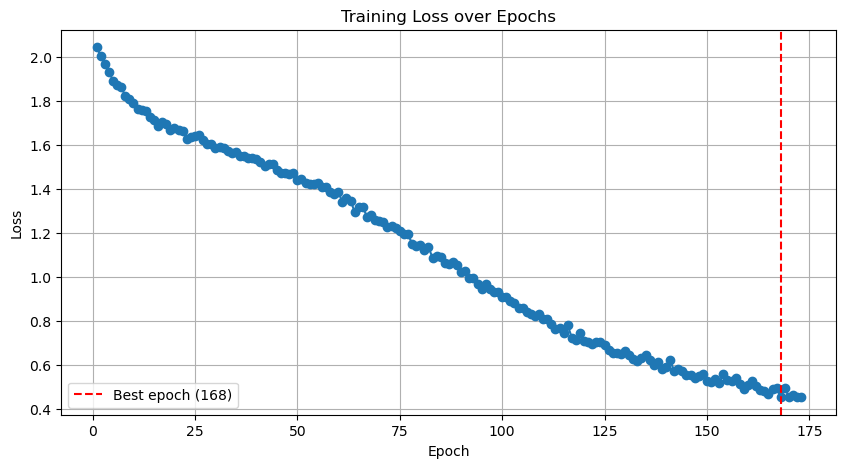

Best loss: 0.452428 at epoch 168
Final loss: 0.454888
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 156. Best loss was at epoch 151


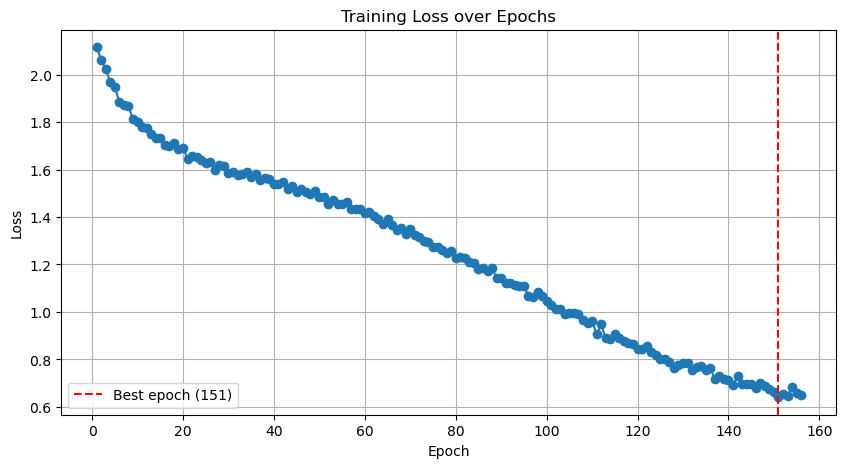

Best loss: 0.640732 at epoch 151
Final loss: 0.652085
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 144. Best loss was at epoch 139


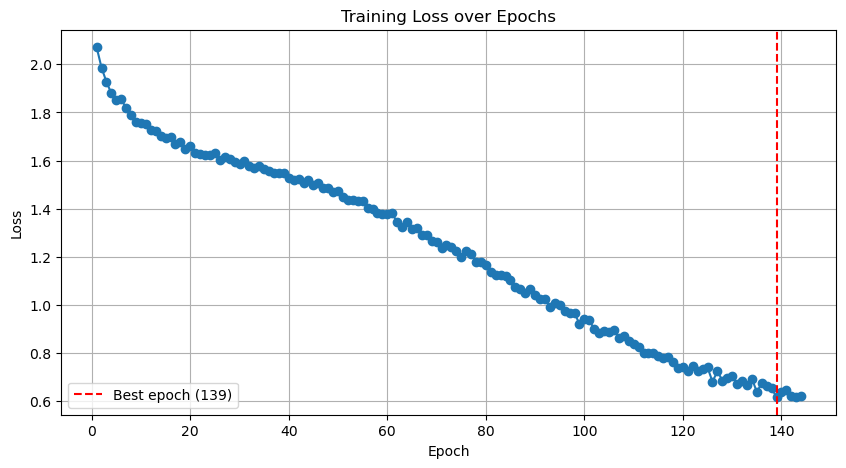

Best loss: 0.615826 at epoch 139
Final loss: 0.620992
{'home_goals_train_accuracy': 0.7158563074352547, 'home_goals_train_precision': 0.40949899021212505, 'home_goals_valid_accuracy': 0.27368421052631575, 'home_goals_valid_precision': 0.13890657587807959, 'home_goals_test_accuracy': 0.24436090225563908, 'home_goals_test_precision': 0.13251141013944248, 'home_goals_train_lte_0_accuracy': 0.8524561403508771, 'home_goals_train_lte_0_accuracy_std': 0.11636814681564099, 'home_goals_train_lte_0_precision': 0.6944861090006097, 'home_goals_train_lte_0_precision_std': 0.2417684536531934, 'home_goals_train_eq_1_accuracy': 0.9079030910609858, 'home_goals_train_eq_1_accuracy_std': 0.10529647136984761, 'home_goals_train_eq_1_precision': 0.8712923152952804, 'home_goals_train_eq_1_precision_std': 0.1668951006092086, 'home_goals_train_eq_2_accuracy': 0.8737176274018379, 'home_goals_train_eq_2_accuracy_std': 0.13004881987617772, 'home_goals_train_eq_2_precision': 0.7710362297212343, 'home_goals_train_e

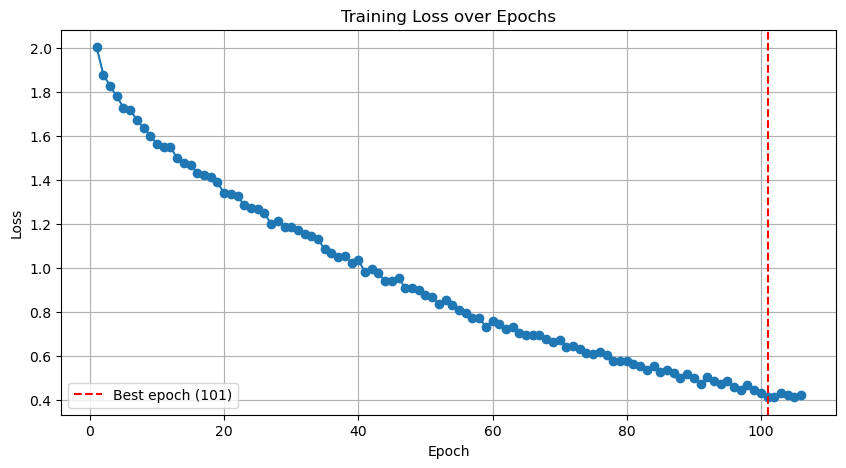

Best loss: 0.411579 at epoch 101
Final loss: 0.421616
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 134. Best loss was at epoch 129


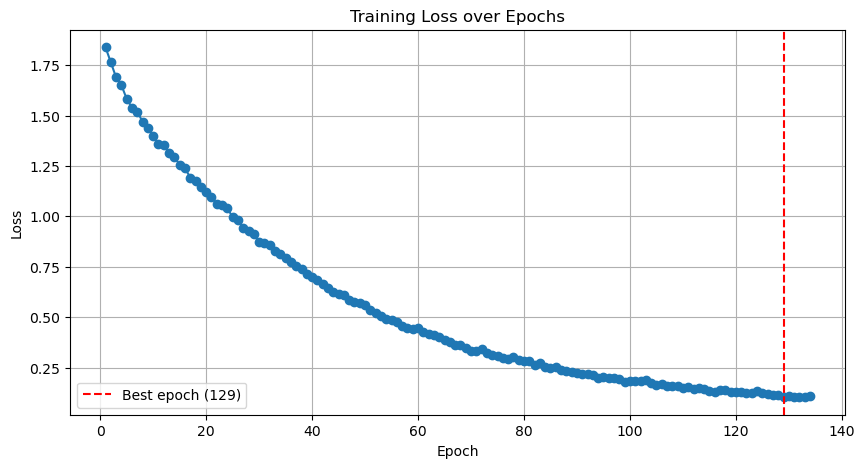

Best loss: 0.103371 at epoch 129
Final loss: 0.107489
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 124. Best loss was at epoch 119


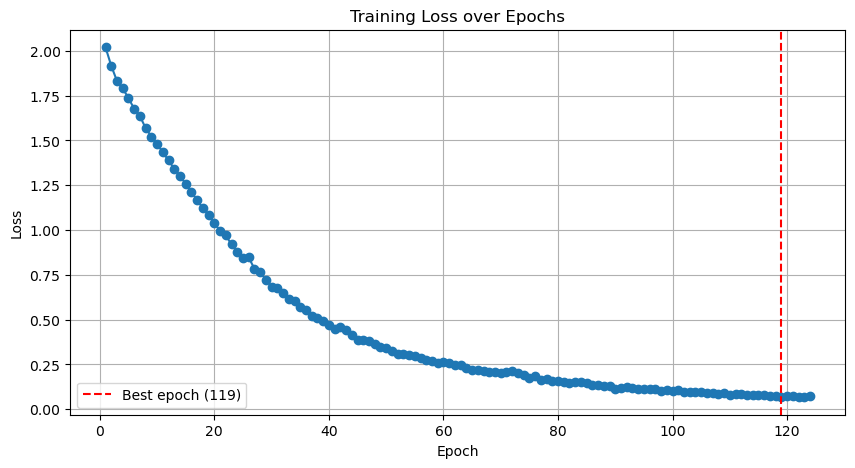

Best loss: 0.067088 at epoch 119
Final loss: 0.073621
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 134. Best loss was at epoch 129


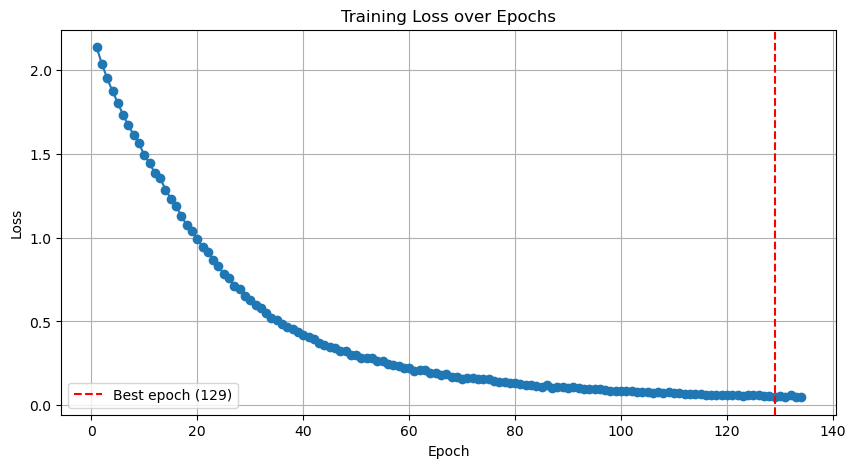

Best loss: 0.048231 at epoch 129
Final loss: 0.051258
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 117. Best loss was at epoch 112


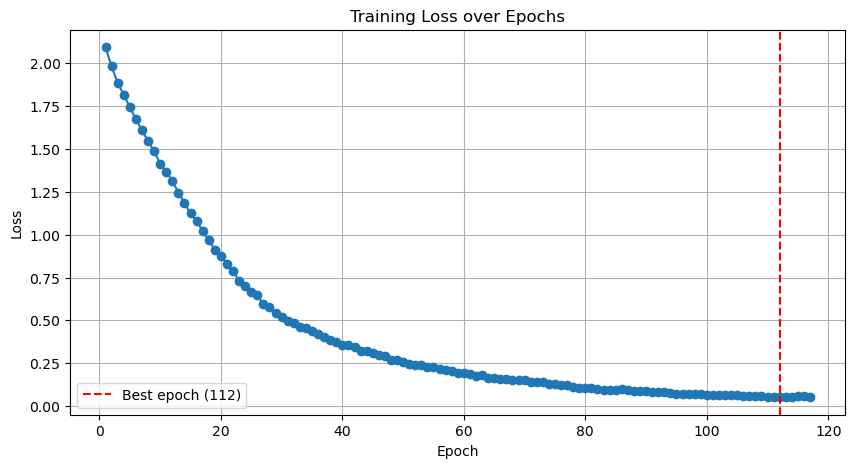

Best loss: 0.051454 at epoch 112
Final loss: 0.054303
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 79. Best loss was at epoch 74


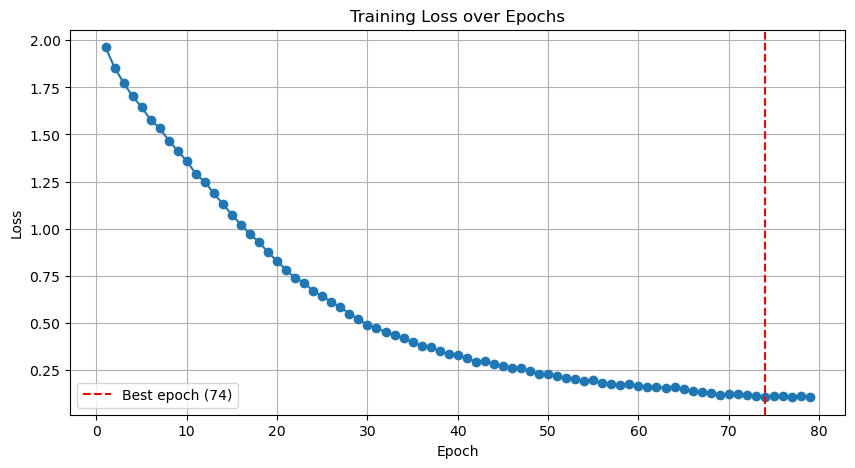

Best loss: 0.105163 at epoch 74
Final loss: 0.105129
{'home_goals_train_accuracy': 0.9967669172932331, 'home_goals_train_precision': 0.9967583324597014, 'home_goals_valid_accuracy': 0.256140350877193, 'home_goals_valid_precision': 0.16341389153007096, 'home_goals_test_accuracy': 0.2631578947368421, 'home_goals_test_precision': 0.16671192490053063, 'home_goals_train_lte_0_accuracy': 0.9994987468671679, 'home_goals_train_lte_0_accuracy_std': 0.0010025062656641825, 'home_goals_train_lte_0_precision': 0.997872340425532, 'home_goals_train_lte_0_precision_std': 0.004255319148936155, 'home_goals_train_eq_1_accuracy': 0.9978696741854638, 'home_goals_train_eq_1_accuracy_std': 0.003954820510791855, 'home_goals_train_eq_1_precision': 0.9948101364522417, 'home_goals_train_eq_1_precision_std': 0.009435321101319408, 'home_goals_train_eq_2_accuracy': 0.9994987468671679, 'home_goals_train_eq_2_accuracy_std': 0.0010025062656641825, 'home_goals_train_eq_2_precision': 0.9979591836734695, 'home_goals_trai

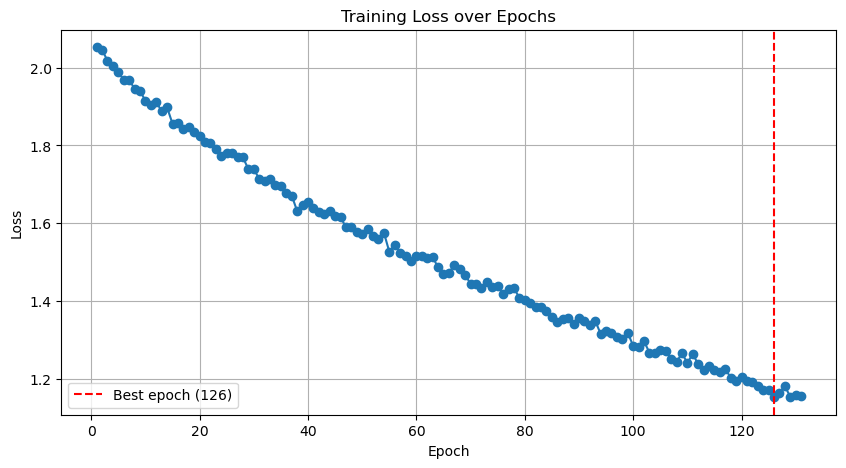

Best loss: 1.152693 at epoch 126
Final loss: 1.156829
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 229. Best loss was at epoch 224


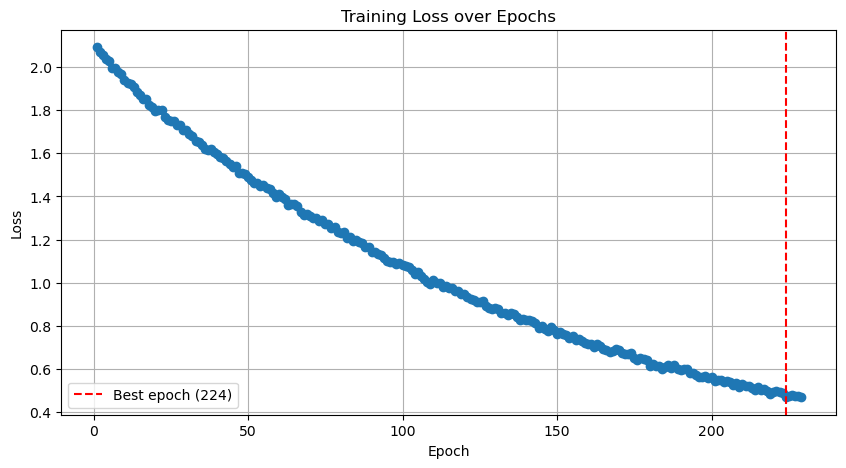

Best loss: 0.468028 at epoch 224
Final loss: 0.468401
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 342. Best loss was at epoch 337


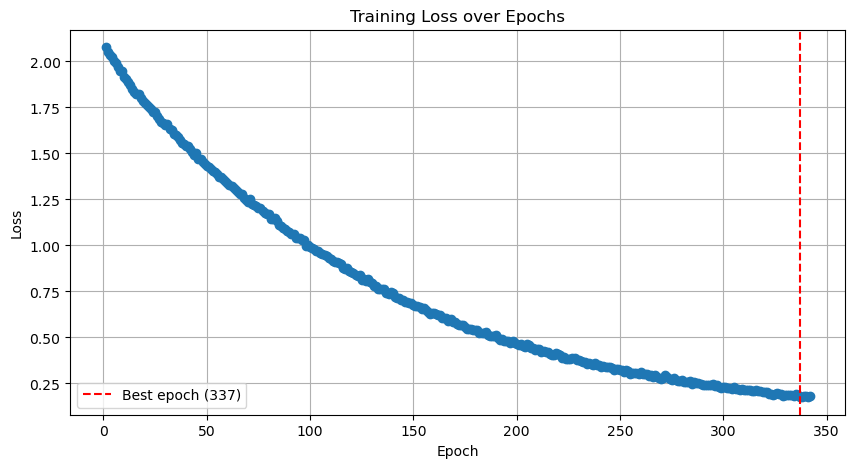

Best loss: 0.174967 at epoch 337
Final loss: 0.181908
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 349. Best loss was at epoch 344


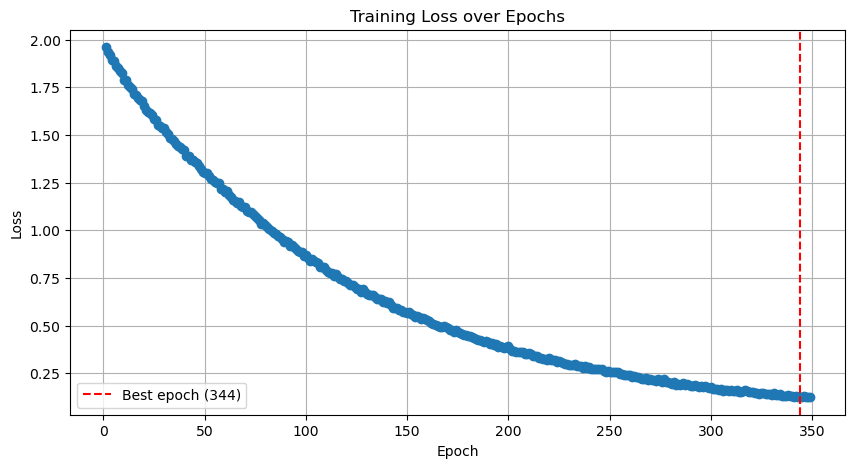

Best loss: 0.124303 at epoch 344
Final loss: 0.127562
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 276. Best loss was at epoch 271


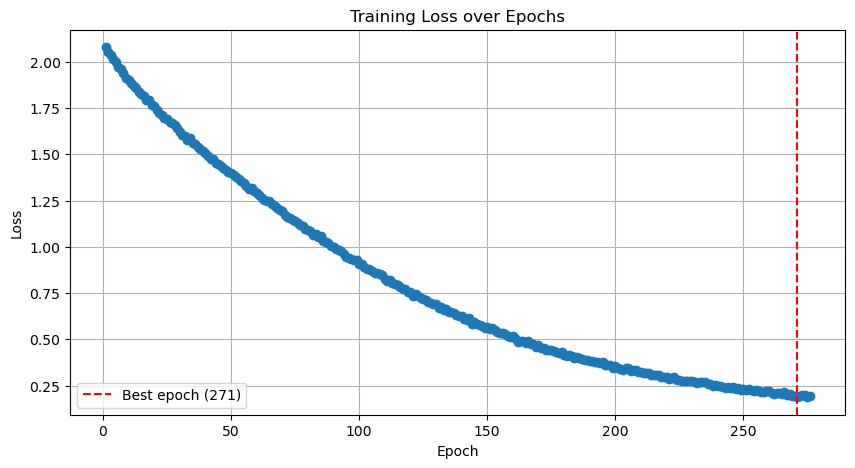

Best loss: 0.187492 at epoch 271
Final loss: 0.191831
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 359. Best loss was at epoch 354


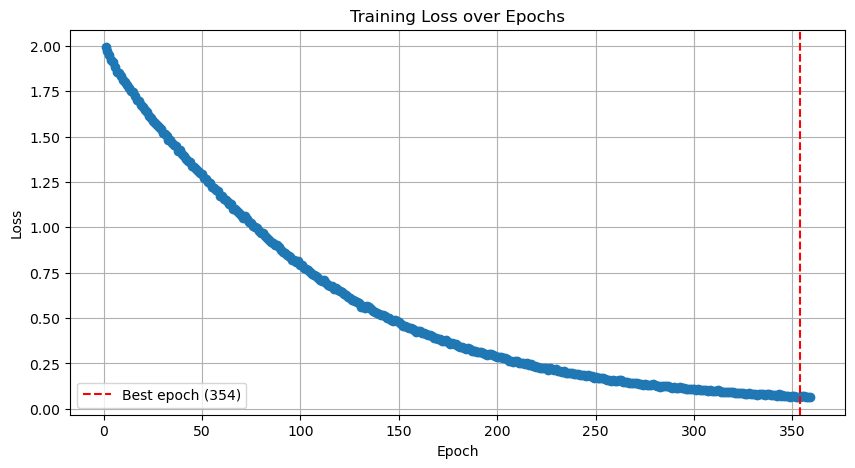

Best loss: 0.063584 at epoch 354
Final loss: 0.066524
{'home_goals_train_accuracy': 0.9931328320802006, 'home_goals_train_precision': 0.9918263665130045, 'home_goals_valid_accuracy': 0.2551378446115288, 'home_goals_valid_precision': 0.14762430714566274, 'home_goals_test_accuracy': 0.24436090225563908, 'home_goals_test_precision': 0.11799108169995508, 'home_goals_train_lte_0_accuracy': 0.997794486215539, 'home_goals_train_lte_0_accuracy_std': 0.0029840353014811668, 'home_goals_train_lte_0_precision': 0.9971134020618557, 'home_goals_train_lte_0_precision_std': 0.005773195876288639, 'home_goals_train_eq_1_accuracy': 0.9965413533834587, 'home_goals_train_eq_1_accuracy_std': 0.004740487385478477, 'home_goals_train_eq_1_precision': 0.9985808049535603, 'home_goals_train_eq_1_precision_std': 0.0017615044558098958, 'home_goals_train_eq_2_accuracy': 0.9977443609022556, 'home_goals_train_eq_2_accuracy_std': 0.00391491211824895, 'home_goals_train_eq_2_precision': 0.992944369063772, 'home_goals_tra

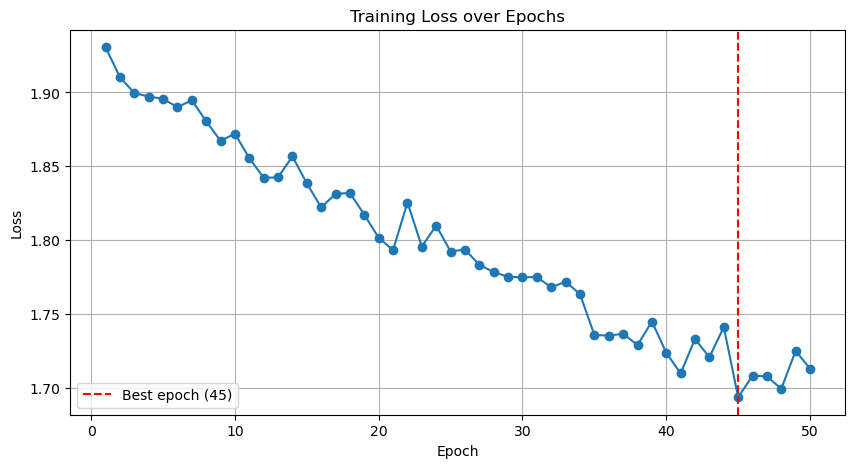

Best loss: 1.693416 at epoch 45
Final loss: 1.712660
Training fold 2/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 69. Best loss was at epoch 64


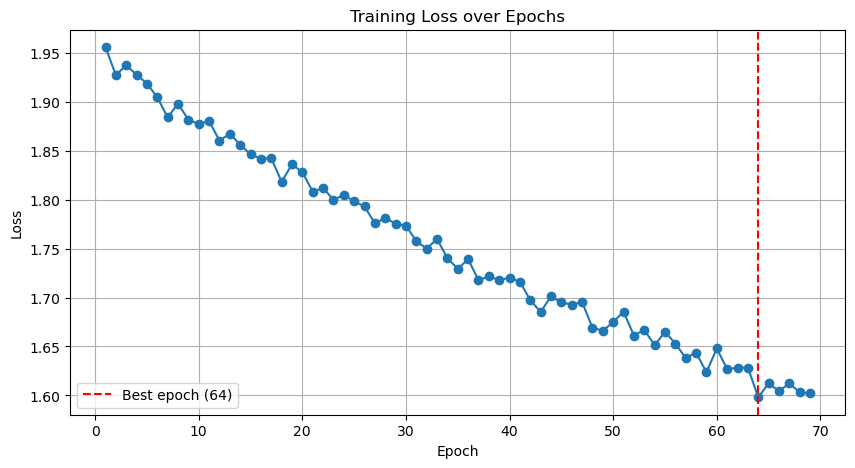

Best loss: 1.598210 at epoch 64
Final loss: 1.602288
Training fold 3/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 167. Best loss was at epoch 162


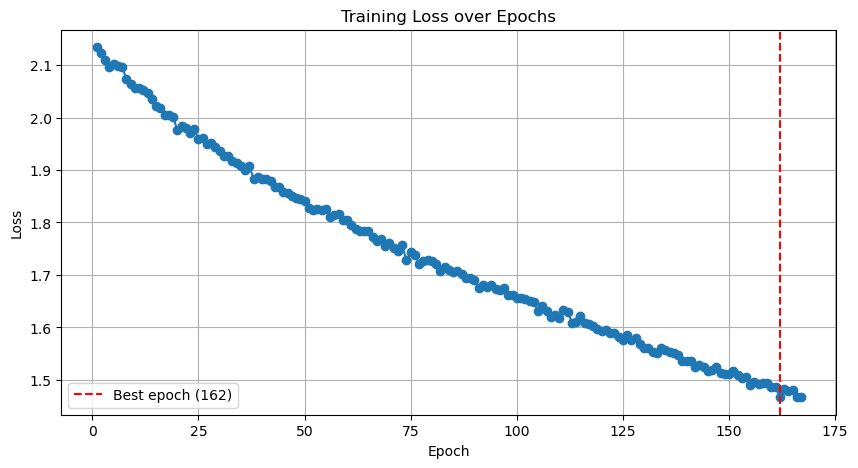

Best loss: 1.466891 at epoch 162
Final loss: 1.468003
Training fold 4/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 252. Best loss was at epoch 247


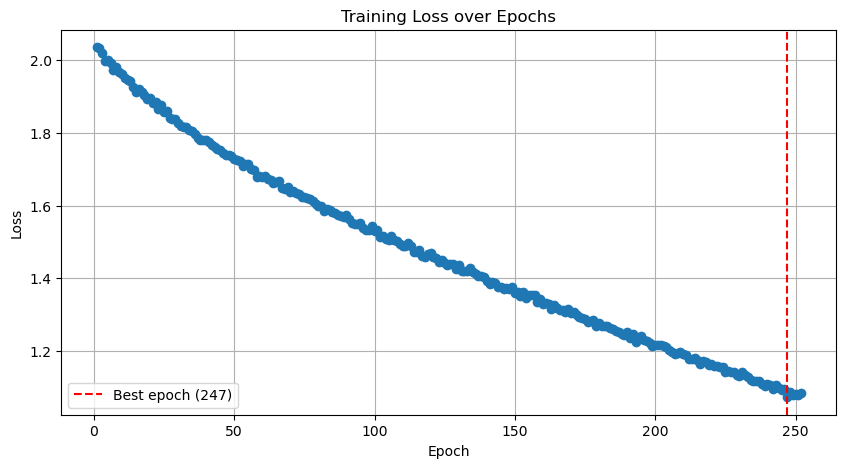

Best loss: 1.073585 at epoch 247
Final loss: 1.084067
Training fold 5/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 392. Best loss was at epoch 387


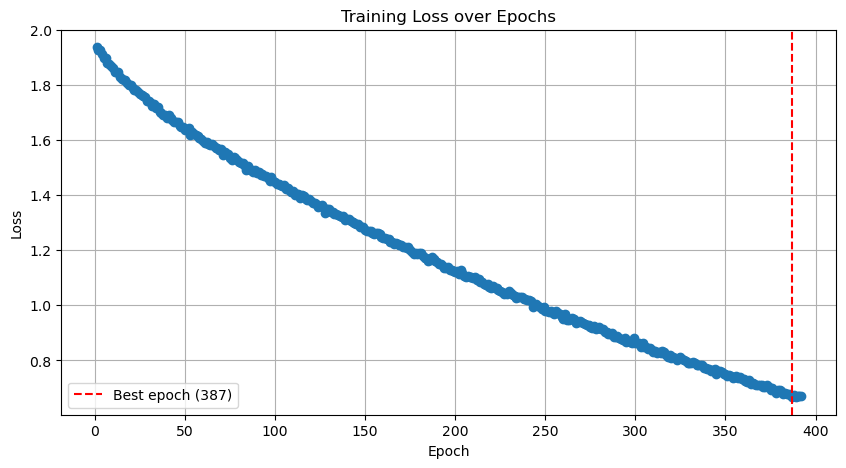

Best loss: 0.666624 at epoch 387
Final loss: 0.671499
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 444. Best loss was at epoch 439


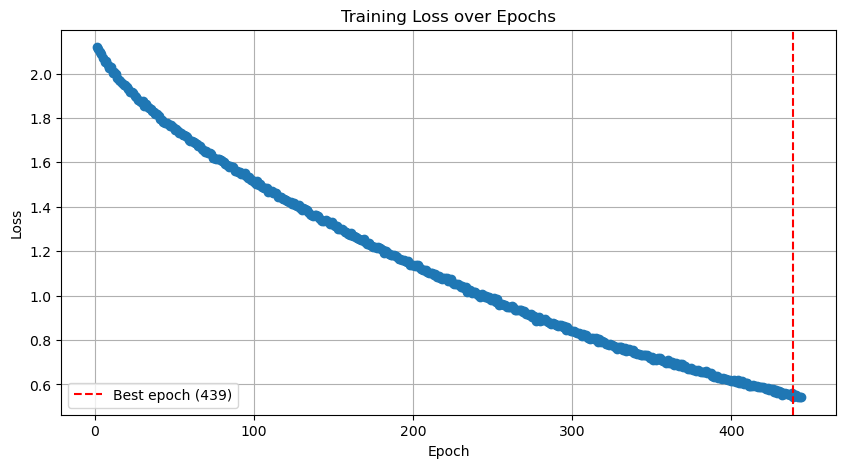

Best loss: 0.542408 at epoch 439
Final loss: 0.542863
{'home_goals_train_accuracy': 0.6894569757727653, 'home_goals_train_precision': 0.6855095196575223, 'home_goals_valid_accuracy': 0.23759398496240602, 'home_goals_valid_precision': 0.12961434008987224, 'home_goals_test_accuracy': 0.24812030075187969, 'home_goals_test_precision': 0.11589442992877379, 'home_goals_train_lte_0_accuracy': 0.8568922305764411, 'home_goals_train_lte_0_accuracy_std': 0.08978029924501418, 'home_goals_train_lte_0_precision': 0.7974920924442128, 'home_goals_train_lte_0_precision_std': 0.16344678082941924, 'home_goals_train_eq_1_accuracy': 0.8502422723475356, 'home_goals_train_eq_1_accuracy_std': 0.11682576961031273, 'home_goals_train_eq_1_precision': 0.8509817052599906, 'home_goals_train_eq_1_precision_std': 0.1652928741693368, 'home_goals_train_eq_2_accuracy': 0.8879281537176273, 'home_goals_train_eq_2_accuracy_std': 0.09288426286204572, 'home_goals_train_eq_2_precision': 0.7752810329936487, 'home_goals_train_e

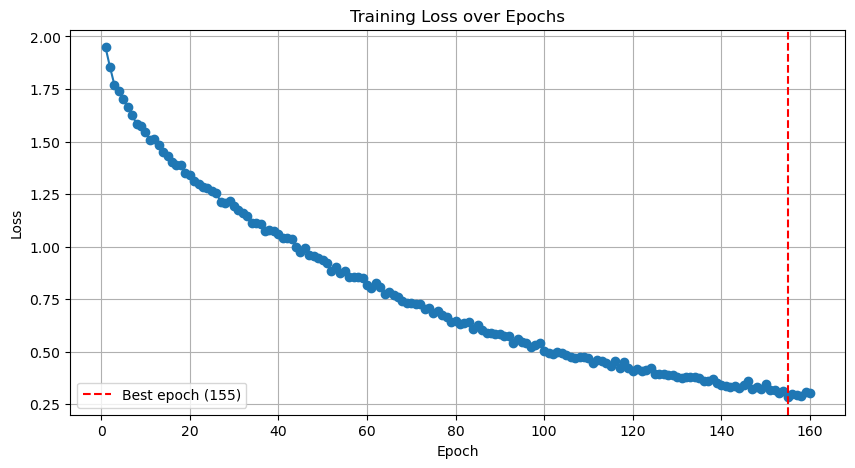

Best loss: 0.283312 at epoch 155
Final loss: 0.305777
Training fold 2/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 156. Best loss was at epoch 151


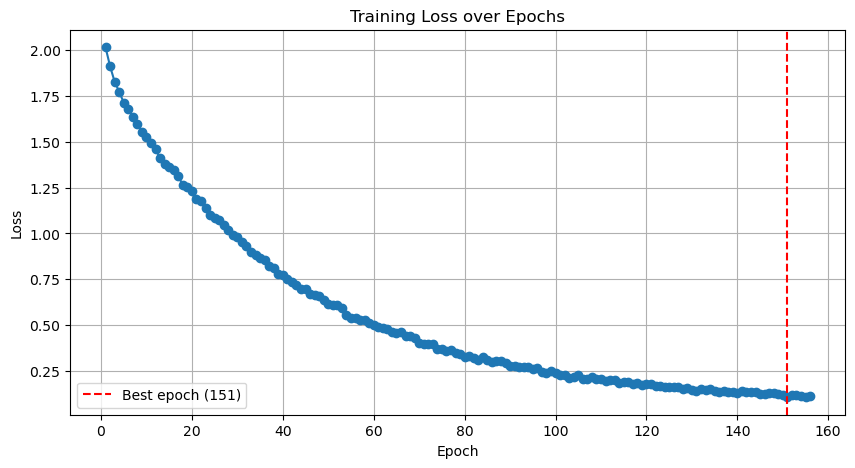

Best loss: 0.105723 at epoch 151
Final loss: 0.112516
Training fold 3/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 161. Best loss was at epoch 156


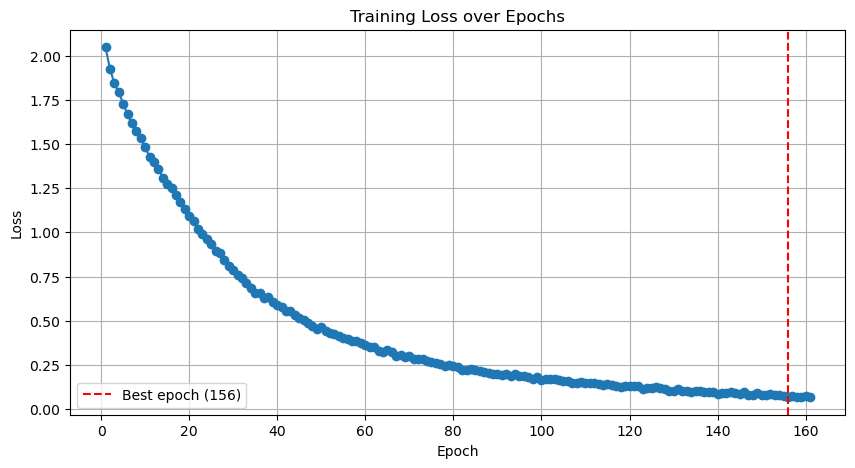

Best loss: 0.066586 at epoch 156
Final loss: 0.066831
Training fold 4/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 99. Best loss was at epoch 94


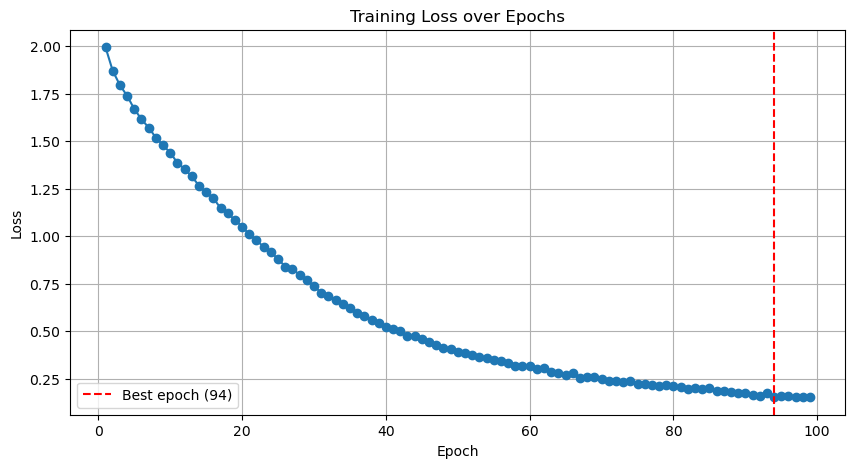

Best loss: 0.153891 at epoch 94
Final loss: 0.154744
Training fold 5/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 89. Best loss was at epoch 84


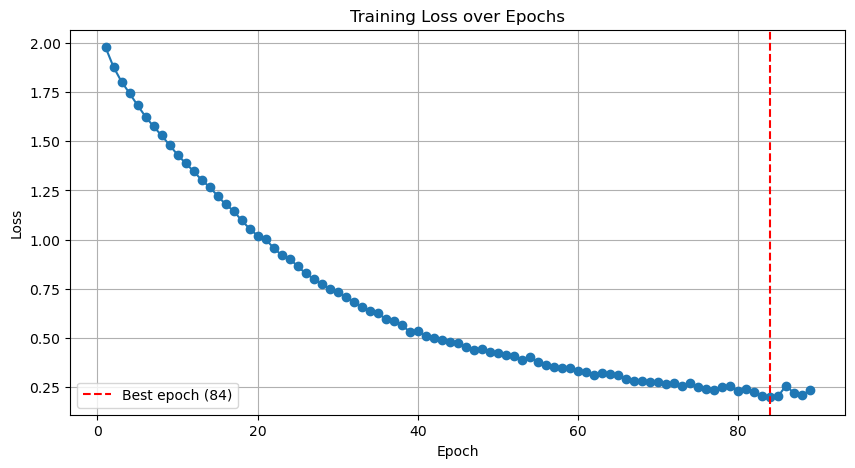

Best loss: 0.199028 at epoch 84
Final loss: 0.235813
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 109. Best loss was at epoch 104


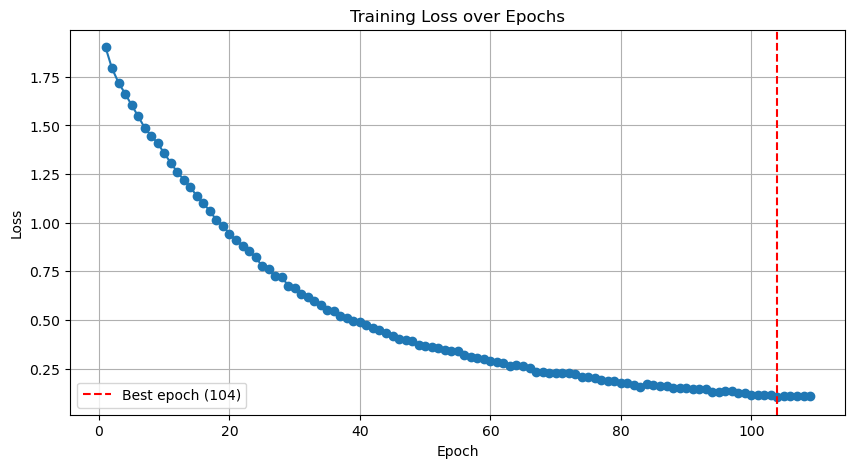

Best loss: 0.102906 at epoch 104
Final loss: 0.110413
{'home_goals_train_accuracy': 0.9863408521303259, 'home_goals_train_precision': 0.8471401480741647, 'home_goals_valid_accuracy': 0.26115288220551375, 'home_goals_valid_precision': 0.15489381038268743, 'home_goals_test_accuracy': 0.2781954887218045, 'home_goals_test_precision': 0.1637009540736249, 'home_goals_train_lte_0_accuracy': 0.997393483709273, 'home_goals_train_lte_0_accuracy_std': 0.0022783595343084605, 'home_goals_train_lte_0_precision': 0.989135654954915, 'home_goals_train_lte_0_precision_std': 0.009588487569958915, 'home_goals_train_eq_1_accuracy': 0.9943609022556391, 'home_goals_train_eq_1_accuracy_std': 0.005227231482359463, 'home_goals_train_eq_1_precision': 0.9828989372734183, 'home_goals_train_eq_1_precision_std': 0.015639407006190088, 'home_goals_train_eq_2_accuracy': 0.9968922305764412, 'home_goals_train_eq_2_accuracy_std': 0.0038095238095238165, 'home_goals_train_eq_2_precision': 0.9874291581108828, 'home_goals_tra

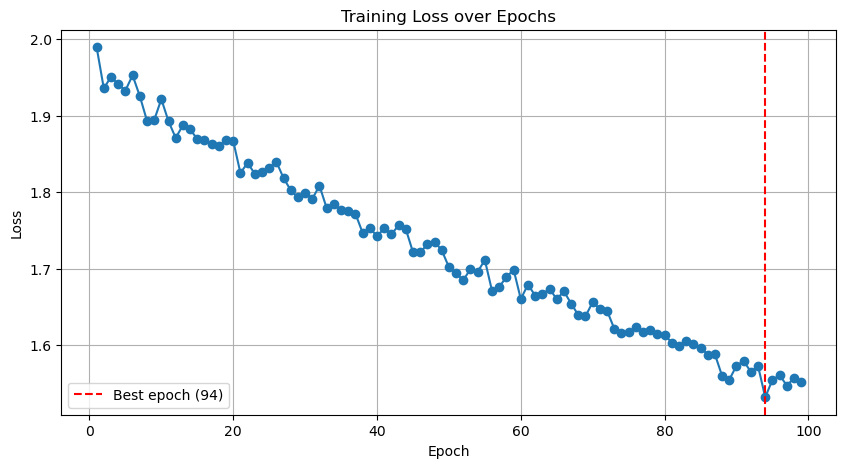

Best loss: 1.531801 at epoch 94
Final loss: 1.551789
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 284. Best loss was at epoch 279


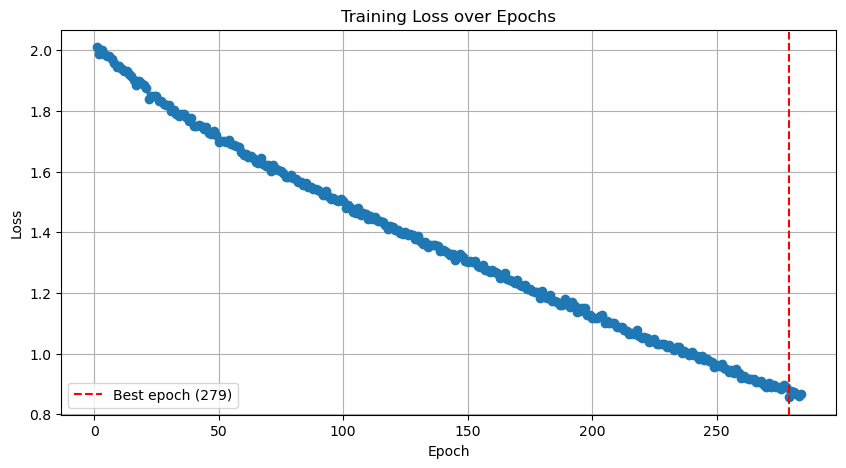

Best loss: 0.856340 at epoch 279
Final loss: 0.866028
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 297. Best loss was at epoch 292


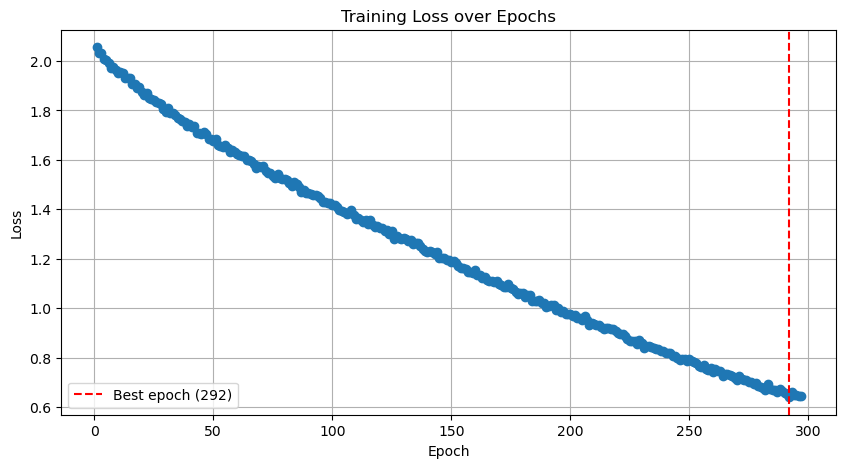

Best loss: 0.640047 at epoch 292
Final loss: 0.645698
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 291. Best loss was at epoch 286


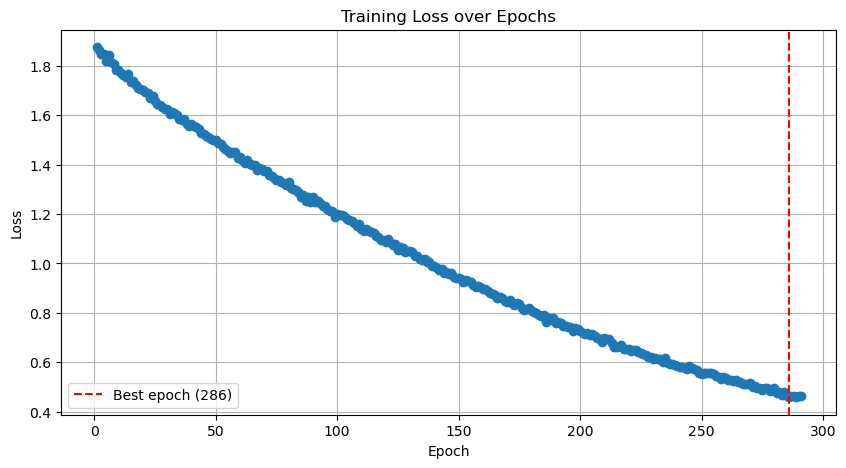

Best loss: 0.458210 at epoch 286
Final loss: 0.463766
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 345. Best loss was at epoch 340


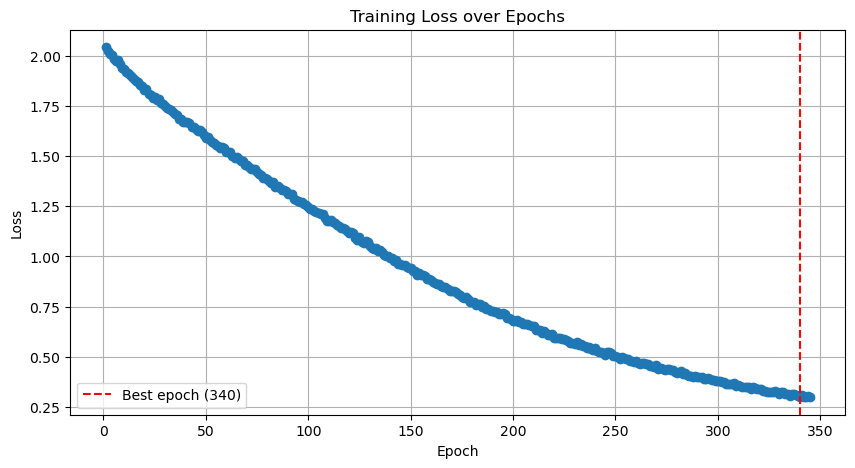

Best loss: 0.298278 at epoch 340
Final loss: 0.299751
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 307. Best loss was at epoch 302


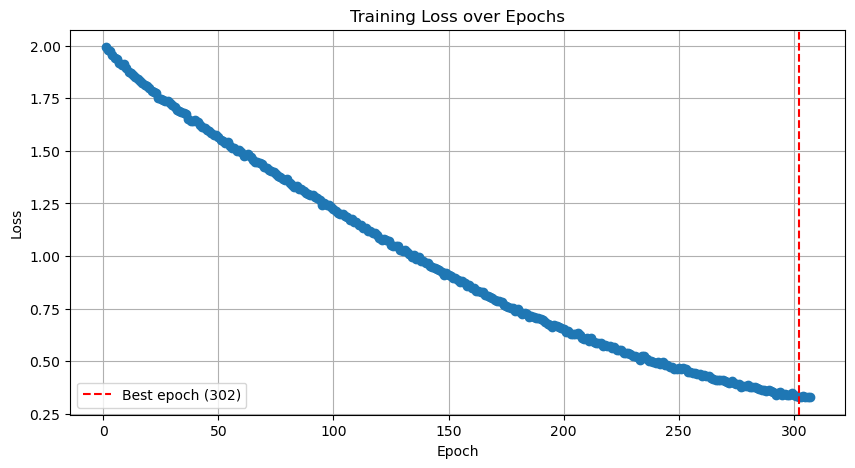

Best loss: 0.328795 at epoch 302
Final loss: 0.328711
{'home_goals_train_accuracy': 0.9303842940685045, 'home_goals_train_precision': 0.9073552159924956, 'home_goals_valid_accuracy': 0.275187969924812, 'home_goals_valid_precision': 0.1754284677679387, 'home_goals_test_accuracy': 0.29699248120300753, 'home_goals_test_precision': 0.1551241047509704, 'home_goals_train_lte_0_accuracy': 0.9754385964912281, 'home_goals_train_lte_0_accuracy_std': 0.030783227787557394, 'home_goals_train_lte_0_precision': 0.9301809590539138, 'home_goals_train_lte_0_precision_std': 0.06893147301893862, 'home_goals_train_eq_1_accuracy': 0.9782205513784461, 'home_goals_train_eq_1_accuracy_std': 0.035682780810237714, 'home_goals_train_eq_1_precision': 0.9639743047129972, 'home_goals_train_eq_1_precision_std': 0.05676538301070359, 'home_goals_train_eq_2_accuracy': 0.9772514619883041, 'home_goals_train_eq_2_accuracy_std': 0.026731432668571174, 'home_goals_train_eq_2_precision': 0.9348790989786094, 'home_goals_train_e

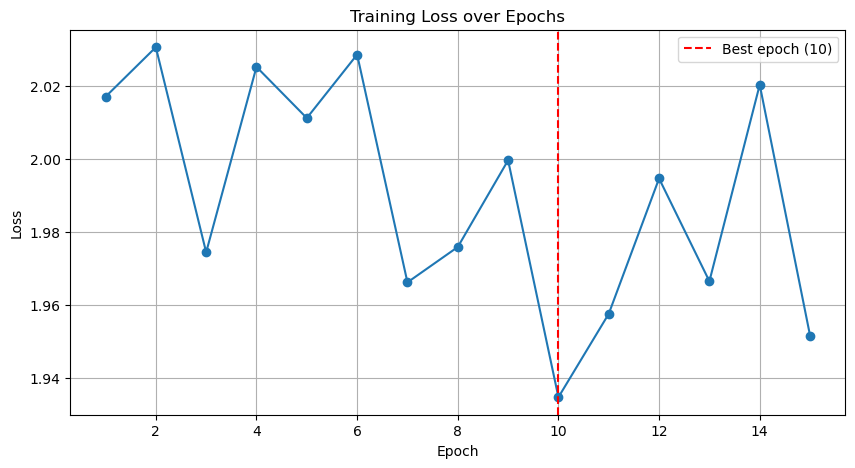

Best loss: 1.934845 at epoch 10
Final loss: 1.951703
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 9. Best loss was at epoch 4


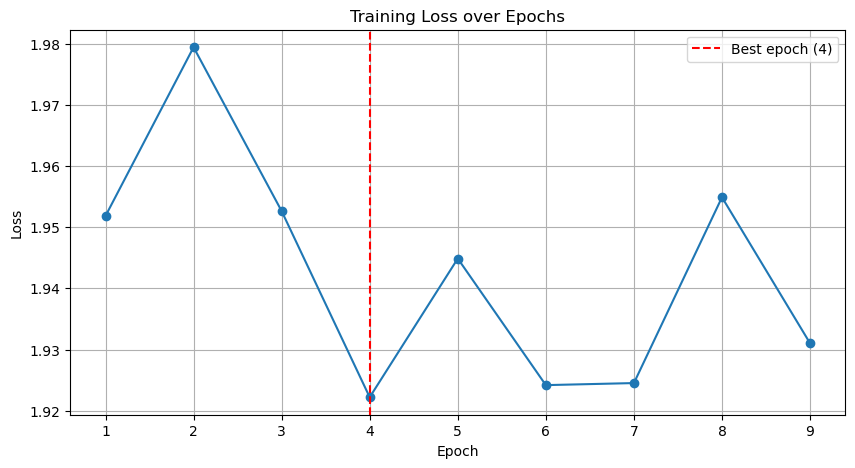

Best loss: 1.922210 at epoch 4
Final loss: 1.931033
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 65. Best loss was at epoch 60


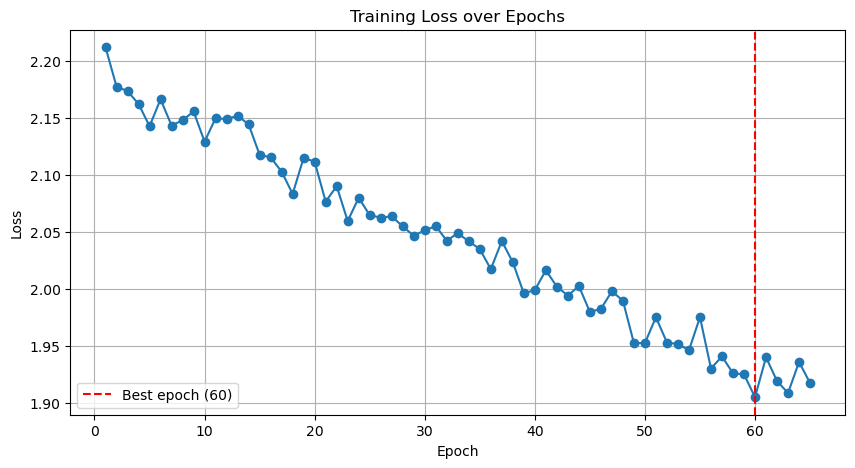

Best loss: 1.904874 at epoch 60
Final loss: 1.917302
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 90. Best loss was at epoch 85


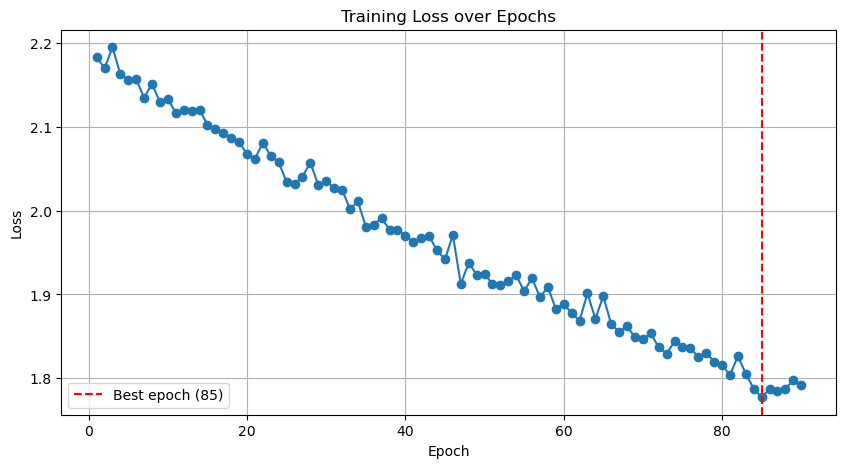

Best loss: 1.777154 at epoch 85
Final loss: 1.791601
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 44. Best loss was at epoch 39


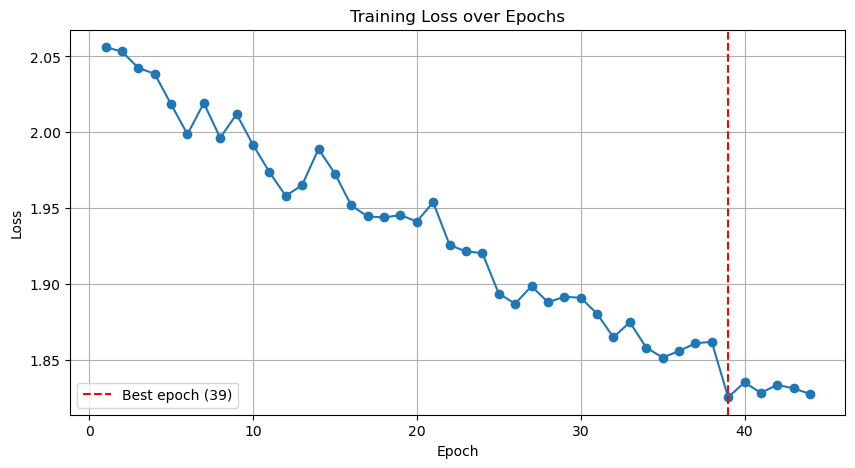

Best loss: 1.825202 at epoch 39
Final loss: 1.827329
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 93. Best loss was at epoch 88


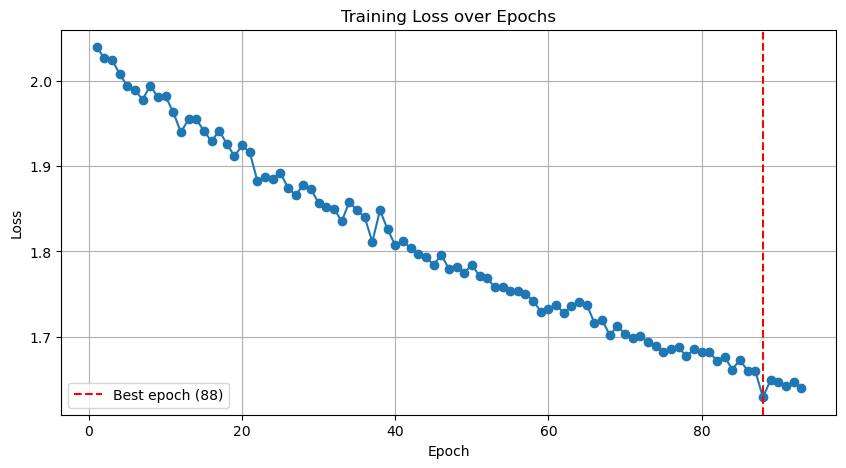

Best loss: 1.628733 at epoch 88
Final loss: 1.639397
{'home_goals_train_accuracy': 0.32903091060985795, 'home_goals_train_precision': 0.27081156041164095, 'home_goals_valid_accuracy': 0.21152882205513784, 'home_goals_valid_precision': 0.12356164189059116, 'home_goals_test_accuracy': 0.3082706766917293, 'home_goals_test_precision': 0.13946827829581165, 'home_goals_train_lte_0_accuracy': 0.7301587301587302, 'home_goals_train_lte_0_accuracy_std': 0.055458423514754454, 'home_goals_train_lte_0_precision': 0.4373262700760138, 'home_goals_train_lte_0_precision_std': 0.11558711990346396, 'home_goals_train_eq_1_accuracy': 0.6837259816207185, 'home_goals_train_eq_1_accuracy_std': 0.06050453612949965, 'home_goals_train_eq_1_precision': 0.5276851906263672, 'home_goals_train_eq_1_precision_std': 0.26203689649507184, 'home_goals_train_eq_2_accuracy': 0.6529156223893067, 'home_goals_train_eq_2_accuracy_std': 0.06176952839048181, 'home_goals_train_eq_2_precision': 0.33235610389858544, 'home_goals_trai

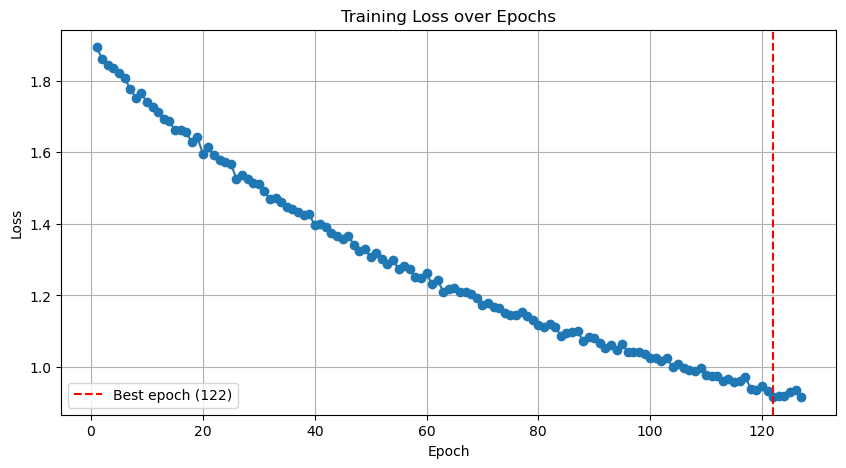

Best loss: 0.915766 at epoch 122
Final loss: 0.917643
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 337. Best loss was at epoch 332


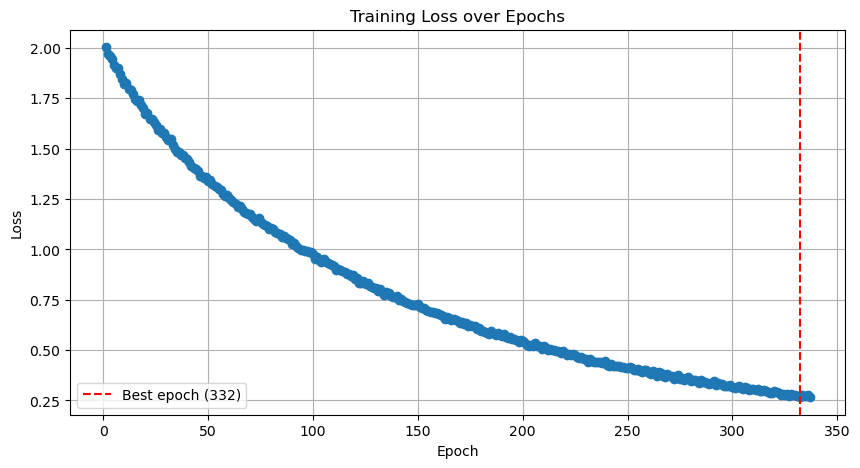

Best loss: 0.265971 at epoch 332
Final loss: 0.265924
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 225. Best loss was at epoch 220


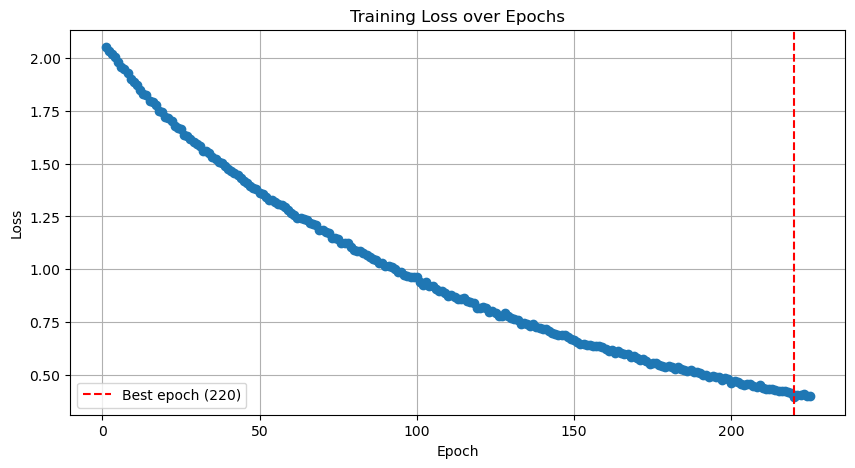

Best loss: 0.393288 at epoch 220
Final loss: 0.396770
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 331. Best loss was at epoch 326


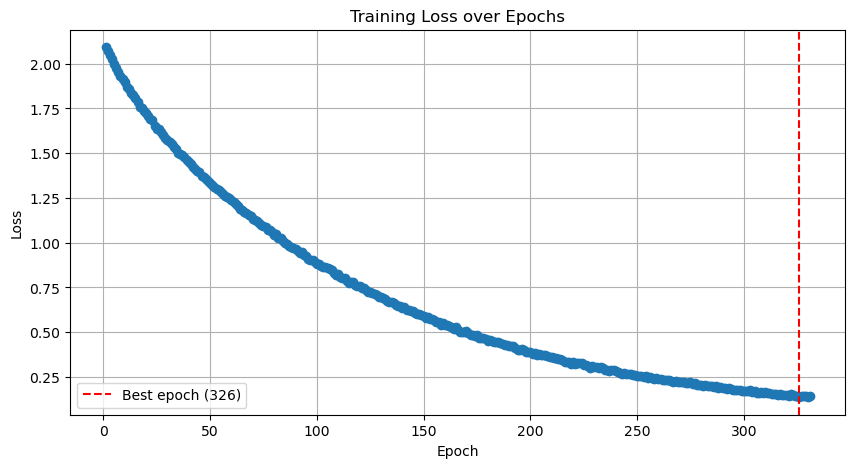

Best loss: 0.136655 at epoch 326
Final loss: 0.140777
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 320. Best loss was at epoch 315


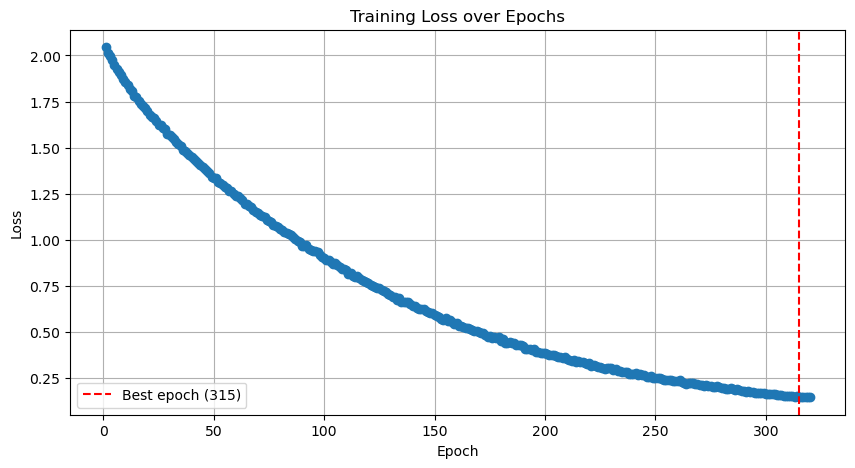

Best loss: 0.145972 at epoch 315
Final loss: 0.146117
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 402. Best loss was at epoch 397


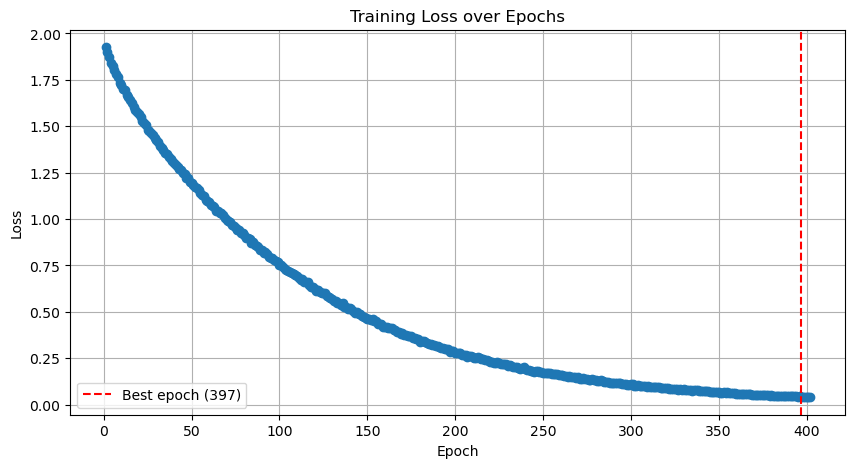

Best loss: 0.039987 at epoch 397
Final loss: 0.041121
{'home_goals_train_accuracy': 0.991779448621554, 'home_goals_train_precision': 0.9953700802220868, 'home_goals_valid_accuracy': 0.281704260651629, 'home_goals_valid_precision': 0.16472144809359351, 'home_goals_test_accuracy': 0.23684210526315788, 'home_goals_test_precision': 0.15694624025384019, 'home_goals_train_lte_0_accuracy': 0.9946532999164578, 'home_goals_train_lte_0_accuracy_std': 0.00987919498686348, 'home_goals_train_lte_0_precision': 0.9860439177413733, 'home_goals_train_lte_0_precision_std': 0.02473425249762201, 'home_goals_train_eq_1_accuracy': 0.9969590643274854, 'home_goals_train_eq_1_accuracy_std': 0.004787368345943877, 'home_goals_train_eq_1_precision': 0.9925134638893282, 'home_goals_train_eq_1_precision_std': 0.012197262554764846, 'home_goals_train_eq_2_accuracy': 0.9959899749373434, 'home_goals_train_eq_2_accuracy_std': 0.006836181301747316, 'home_goals_train_eq_2_precision': 0.9904030429376052, 'home_goals_train_

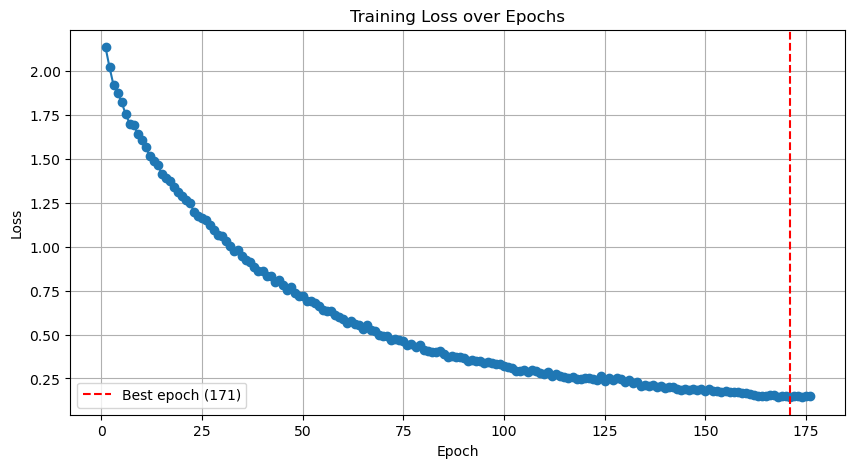

Best loss: 0.143350 at epoch 171
Final loss: 0.150154
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 158. Best loss was at epoch 153


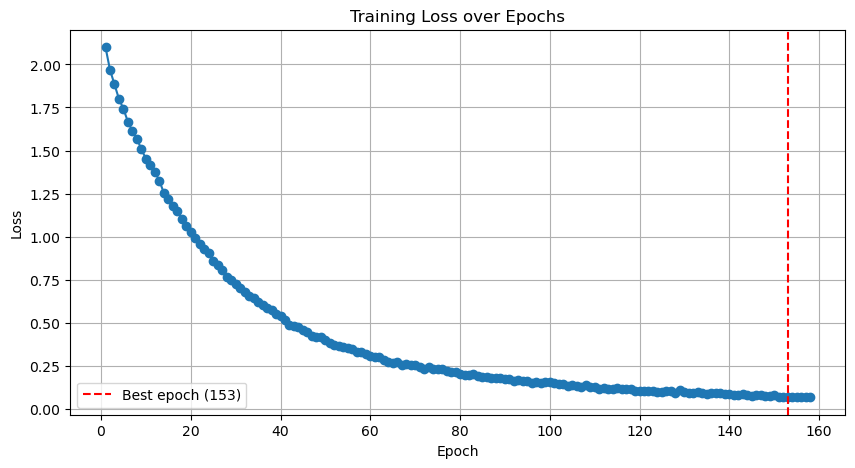

Best loss: 0.067695 at epoch 153
Final loss: 0.068504
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 136. Best loss was at epoch 131


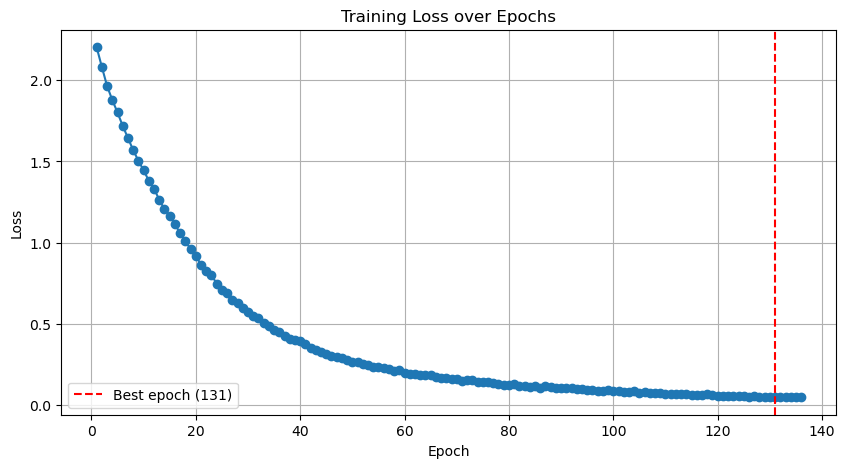

Best loss: 0.049724 at epoch 131
Final loss: 0.050370
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 119. Best loss was at epoch 114


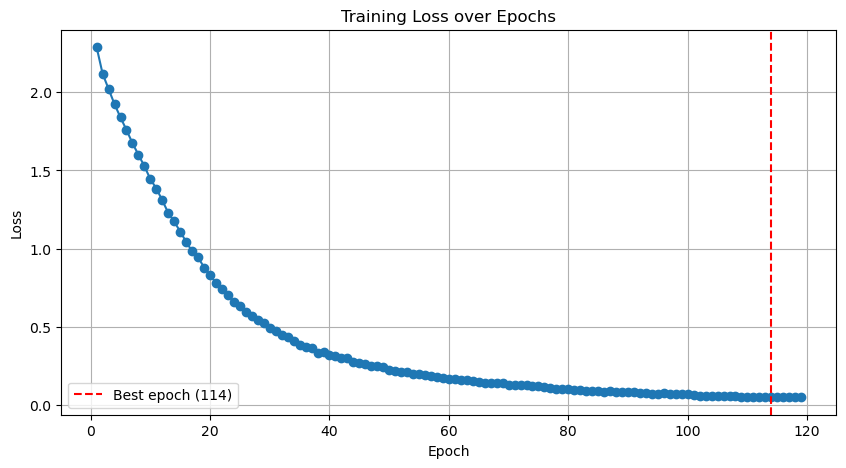

Best loss: 0.048733 at epoch 114
Final loss: 0.050113
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 133. Best loss was at epoch 128


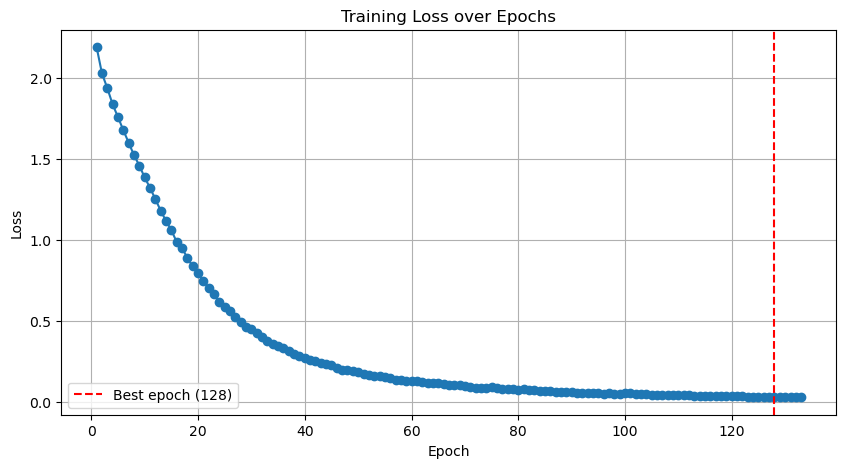

Best loss: 0.027078 at epoch 128
Final loss: 0.027216
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 128. Best loss was at epoch 123


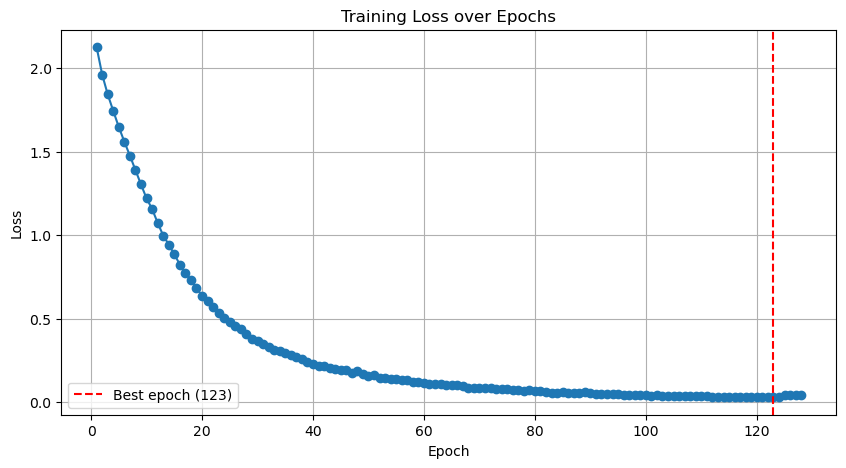

Best loss: 0.030247 at epoch 123
Final loss: 0.045026
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.2837092731829574, 'away_goals_valid_precision': 0.14742949057419624, 'away_goals_test_accuracy': 0.2781954887218045, 'away_goals_test_precision': 0.18535529661779823, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_eq_1_accuracy': 1.0, 'away_goals_train_eq_1_accuracy_std': 0.0, 'away_goals_train_eq_1_precision': 1.0, 'away_goals_train_eq_1_precision_std': 0.0, 'away_goals_train_eq_2_accuracy': 1.0, 'away_goals_train_eq_2_accuracy_std': 0.0, 'away_goals_train_eq_2_precision': 1.0, 'away_goals_train_eq_2_precision_std': 0.0, 'away_goals_train_eq_3_accuracy': 1.0, 'away_goals_train_eq_3_accuracy_std': 0.0, 'away_goals_train_eq_3_precision': 1.0, 'away_goals_train_eq_3_precision_std': 0.0, 'away_goal

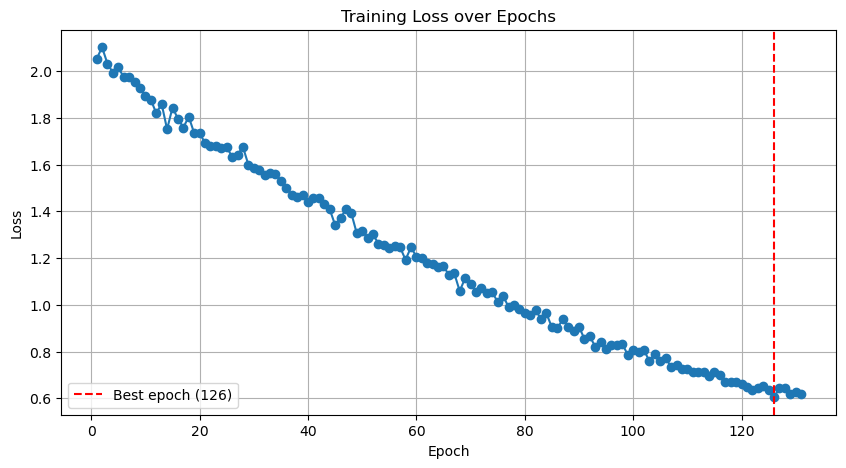

Best loss: 0.604716 at epoch 126
Final loss: 0.617476
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 165. Best loss was at epoch 160


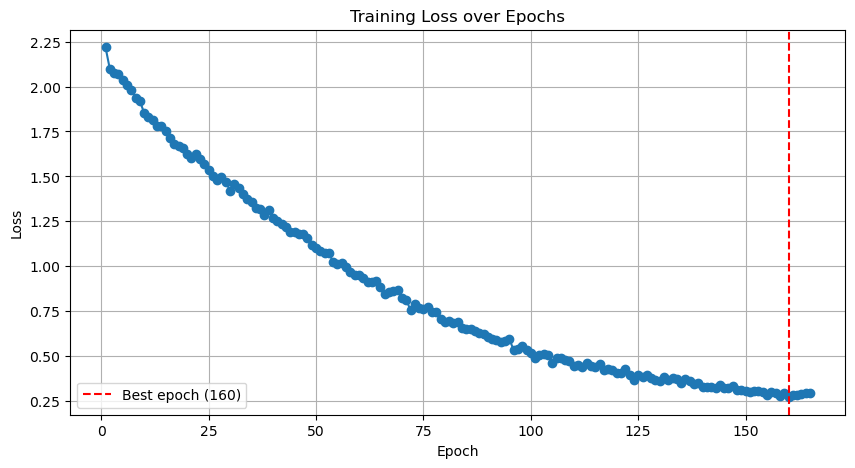

Best loss: 0.271350 at epoch 160
Final loss: 0.295251
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 153. Best loss was at epoch 148


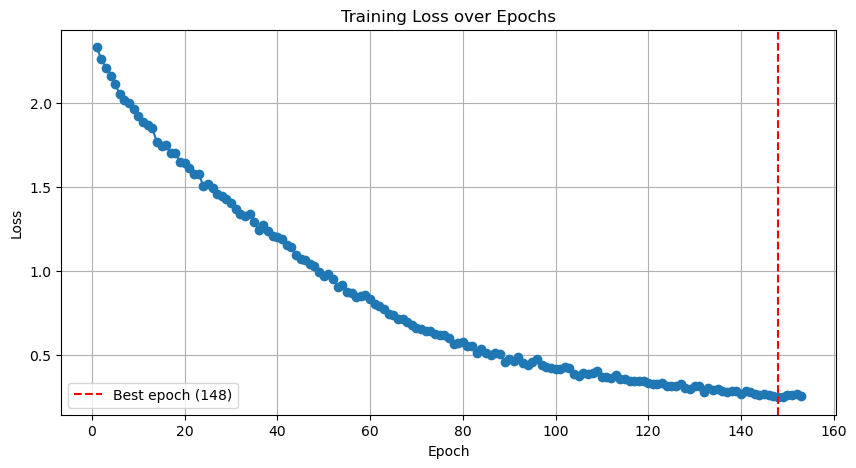

Best loss: 0.249806 at epoch 148
Final loss: 0.256934
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 135. Best loss was at epoch 130


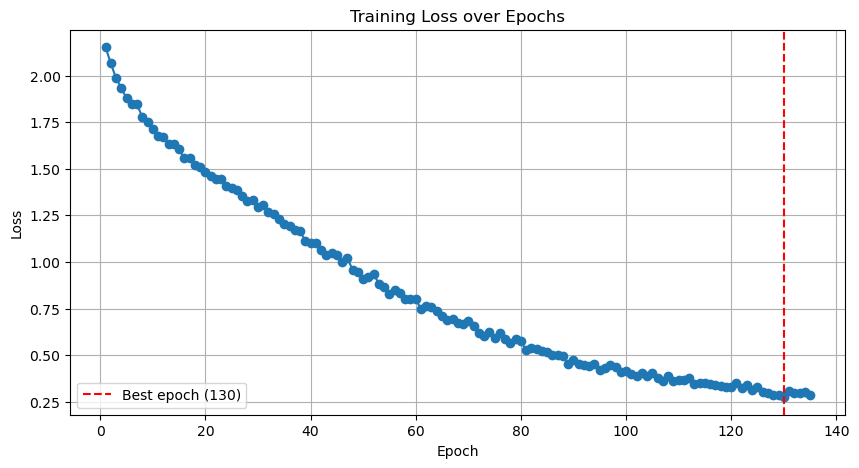

Best loss: 0.274520 at epoch 130
Final loss: 0.283895
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 136. Best loss was at epoch 131


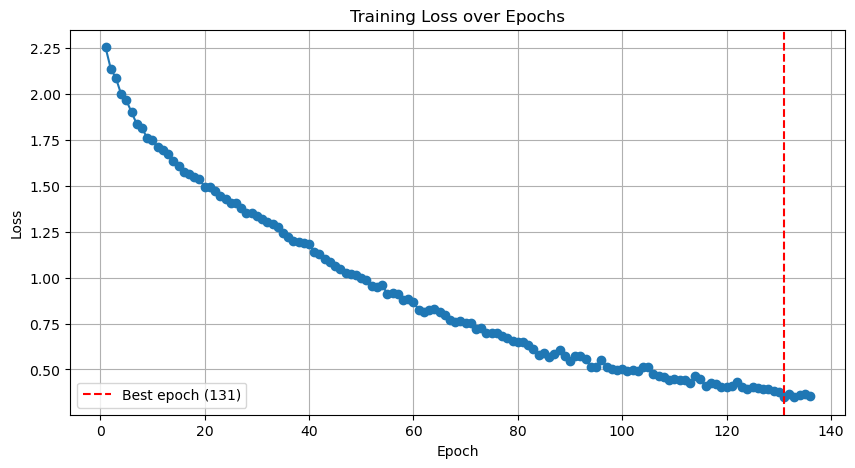

Best loss: 0.349058 at epoch 131
Final loss: 0.356493
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 171. Best loss was at epoch 166


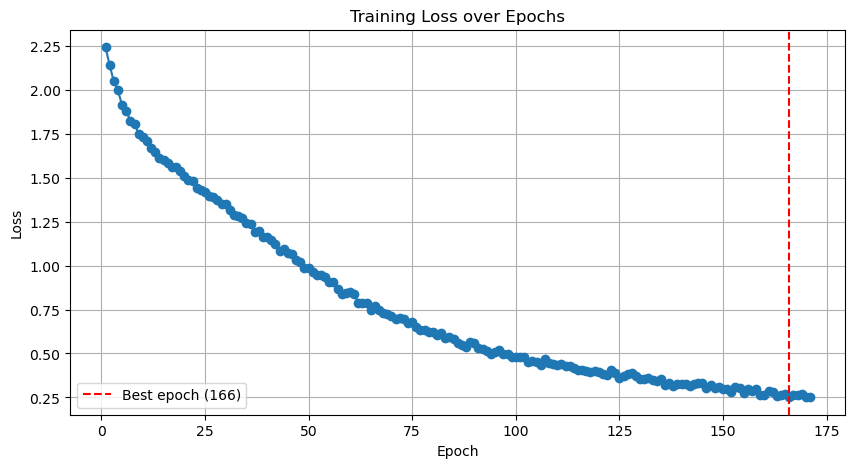

Best loss: 0.251018 at epoch 166
Final loss: 0.253299
{'away_goals_train_accuracy': 0.9653216374269006, 'away_goals_train_precision': 0.5516658445002541, 'away_goals_valid_accuracy': 0.275187969924812, 'away_goals_valid_precision': 0.1324112150235623, 'away_goals_test_accuracy': 0.2819548872180451, 'away_goals_test_precision': 0.1620746445155894, 'away_goals_train_lte_0_accuracy': 0.9983709273182957, 'away_goals_train_lte_0_accuracy_std': 0.0013496653651966413, 'away_goals_train_lte_0_precision': 0.9971285892634206, 'away_goals_train_lte_0_precision_std': 0.003549269440800624, 'away_goals_train_eq_1_accuracy': 0.9951461988304093, 'away_goals_train_eq_1_accuracy_std': 0.003930426928300001, 'away_goals_train_eq_1_precision': 0.9866620073655616, 'away_goals_train_eq_1_precision_std': 0.010599817357804298, 'away_goals_train_eq_2_accuracy': 0.986482873851295, 'away_goals_train_eq_2_accuracy_std': 0.011728371221893873, 'away_goals_train_eq_2_precision': 0.9454792386730171, 'away_goals_train_

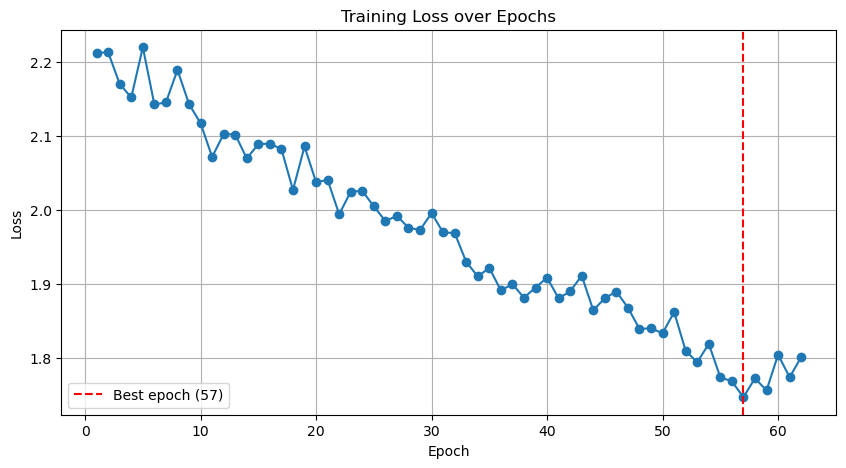

Best loss: 1.746415 at epoch 57
Final loss: 1.800661
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 77. Best loss was at epoch 72


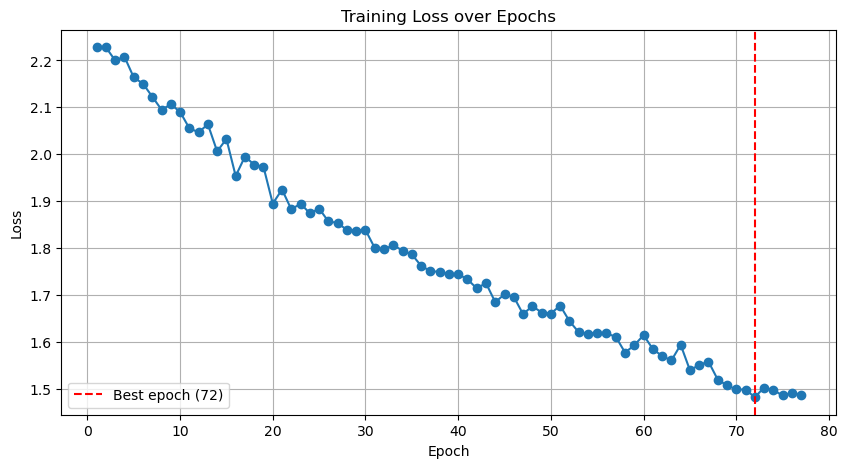

Best loss: 1.482903 at epoch 72
Final loss: 1.488210
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 220. Best loss was at epoch 215


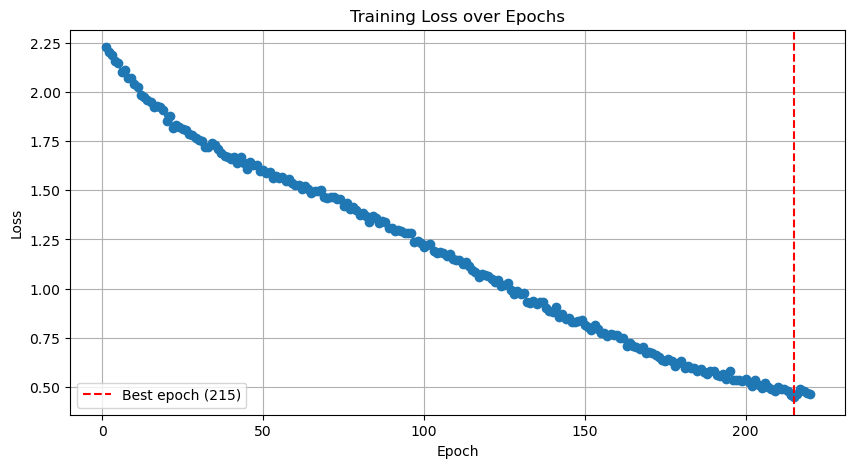

Best loss: 0.447523 at epoch 215
Final loss: 0.465912
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 191. Best loss was at epoch 186


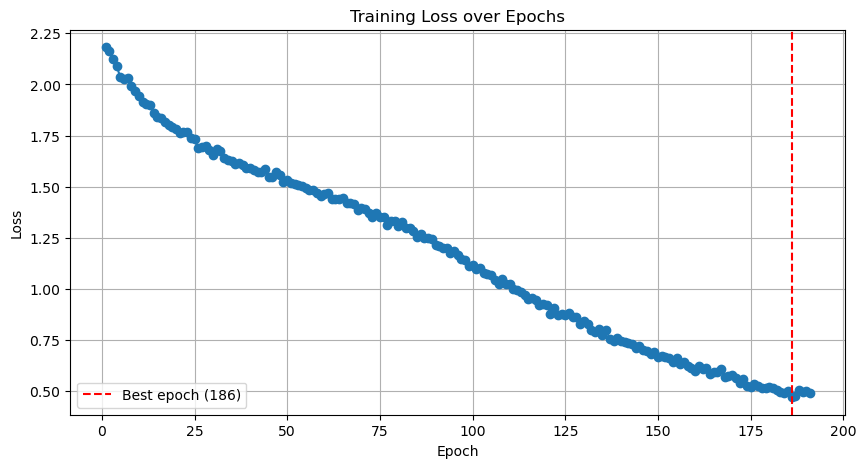

Best loss: 0.468863 at epoch 186
Final loss: 0.489837
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 217. Best loss was at epoch 212


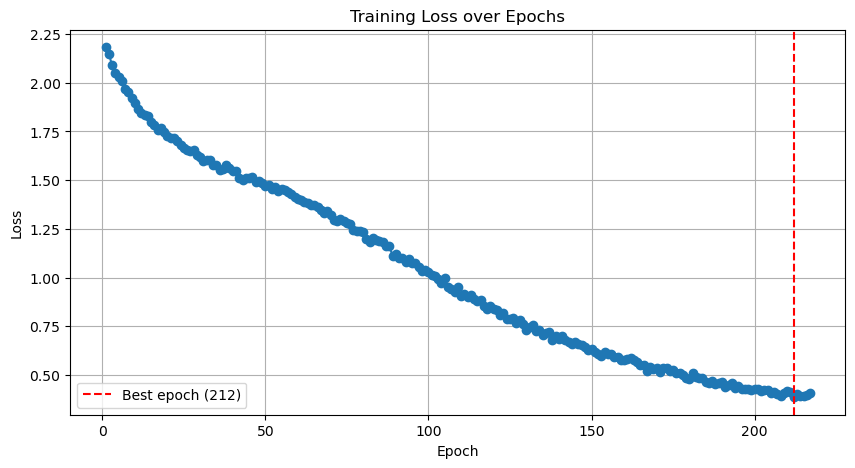

Best loss: 0.386451 at epoch 212
Final loss: 0.407176
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 208. Best loss was at epoch 203


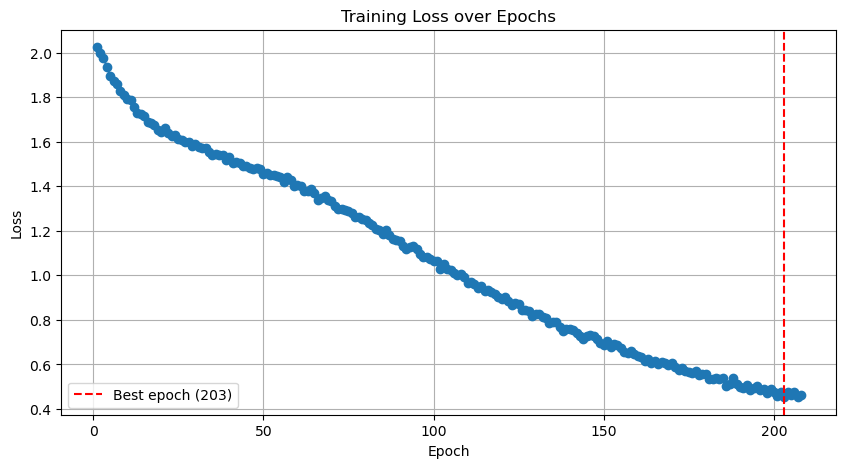

Best loss: 0.452813 at epoch 203
Final loss: 0.461565
{'away_goals_train_accuracy': 0.787953216374269, 'away_goals_train_precision': 0.446167625817386, 'away_goals_valid_accuracy': 0.293734335839599, 'away_goals_valid_precision': 0.13220093278100917, 'away_goals_test_accuracy': 0.2593984962406015, 'away_goals_test_precision': 0.14595120582963345, 'away_goals_train_lte_0_accuracy': 0.8530409356725146, 'away_goals_train_lte_0_accuracy_std': 0.19665959432290298, 'away_goals_train_lte_0_precision': 0.7908964058718684, 'away_goals_train_lte_0_precision_std': 0.2622146296647104, 'away_goals_train_eq_1_accuracy': 0.9048705096073517, 'away_goals_train_eq_1_accuracy_std': 0.1219889254234261, 'away_goals_train_eq_1_precision': 0.8984247952883729, 'away_goals_train_eq_1_precision_std': 0.12274329919247913, 'away_goals_train_eq_2_accuracy': 0.9315538847117795, 'away_goals_train_eq_2_accuracy_std': 0.08107389407448075, 'away_goals_train_eq_2_precision': 0.872601653268563, 'away_goals_train_eq_2_pre

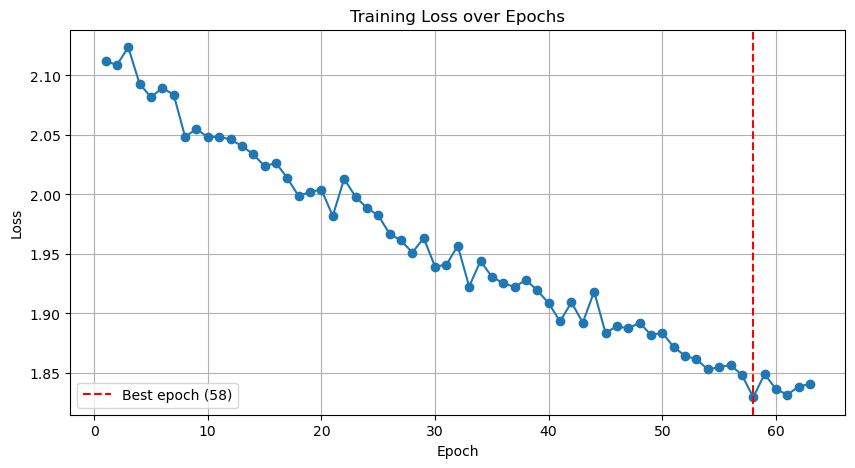

Best loss: 1.829650 at epoch 58
Final loss: 1.840787
Training fold 2/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 133. Best loss was at epoch 128


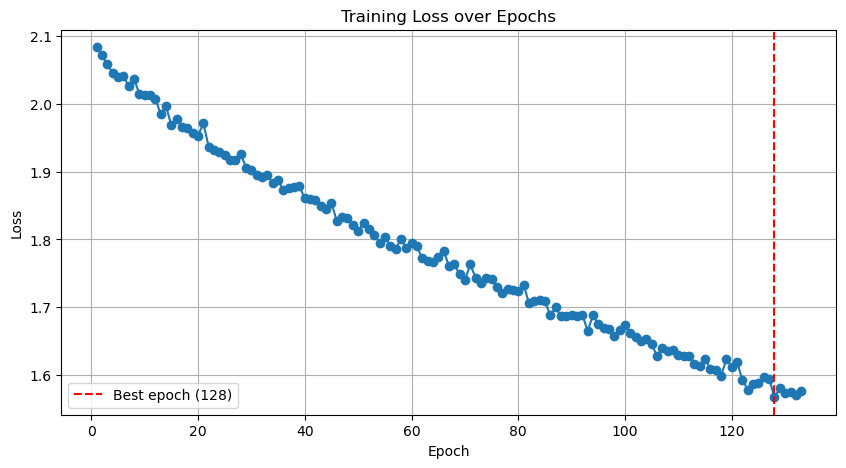

Best loss: 1.567113 at epoch 128
Final loss: 1.576769
Training fold 3/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 329. Best loss was at epoch 324


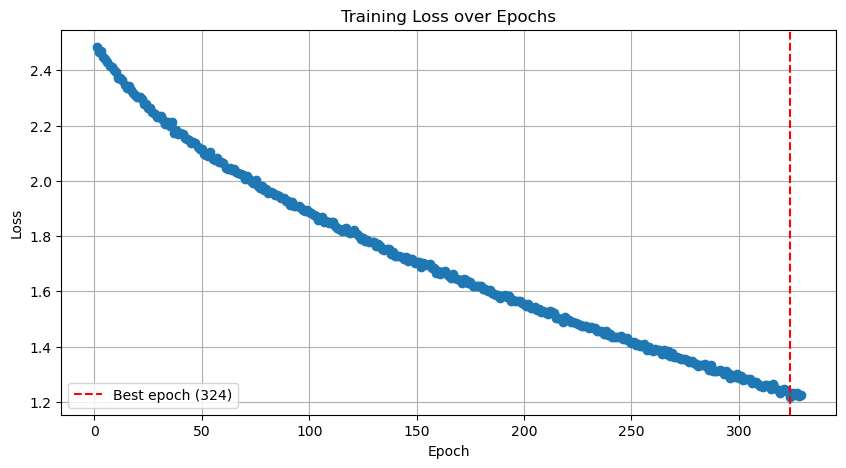

Best loss: 1.216980 at epoch 324
Final loss: 1.224195
Training fold 4/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 408. Best loss was at epoch 403


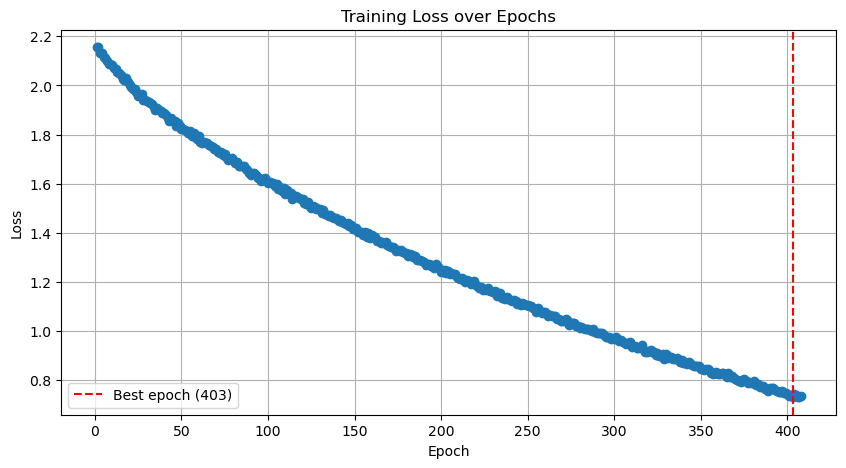

Best loss: 0.730619 at epoch 403
Final loss: 0.734875
Training fold 5/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 397. Best loss was at epoch 392


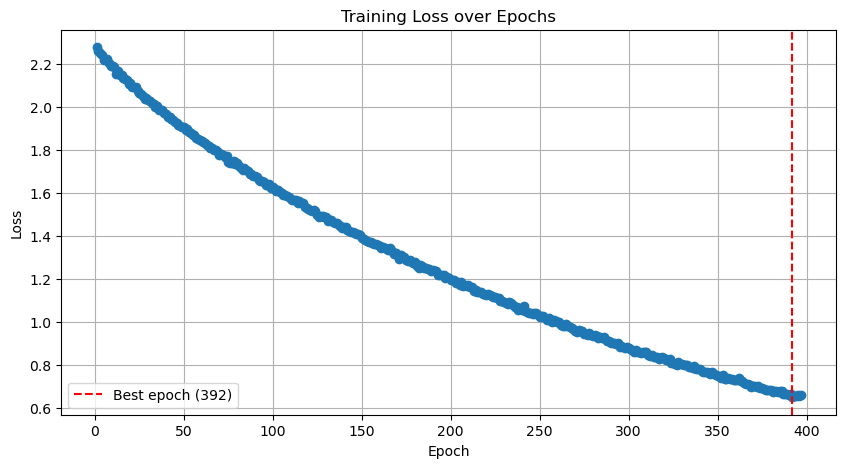

Best loss: 0.649059 at epoch 392
Final loss: 0.657936
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 340. Best loss was at epoch 335


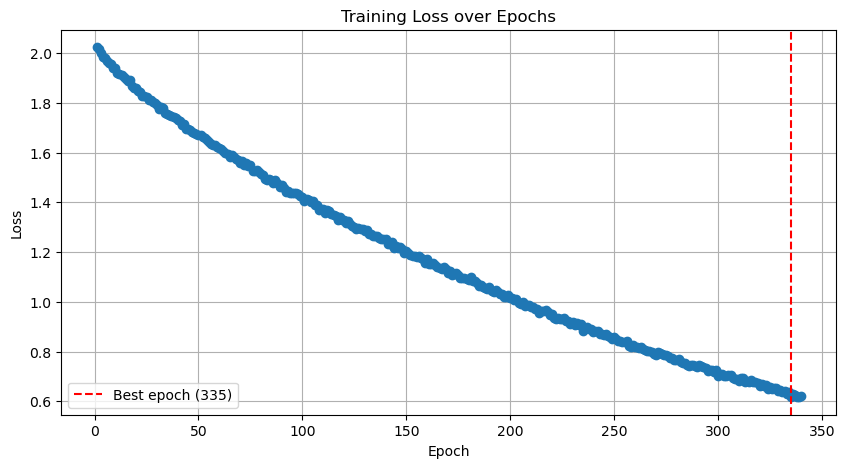

Best loss: 0.616625 at epoch 335
Final loss: 0.621462
{'away_goals_train_accuracy': 0.8193567251461988, 'away_goals_train_precision': 0.7089890866946837, 'away_goals_valid_accuracy': 0.26867167919799495, 'away_goals_valid_precision': 0.11862342960620012, 'away_goals_test_accuracy': 0.2518796992481203, 'away_goals_test_precision': 0.12765436318067896, 'away_goals_train_lte_0_accuracy': 0.906750208855472, 'away_goals_train_lte_0_accuracy_std': 0.10999729929602804, 'away_goals_train_lte_0_precision': 0.9805212764538351, 'away_goals_train_lte_0_precision_std': 0.012770273479896822, 'away_goals_train_eq_1_accuracy': 0.9233416875522138, 'away_goals_train_eq_1_accuracy_std': 0.09223909069220503, 'away_goals_train_eq_1_precision': 0.8630353812849728, 'away_goals_train_eq_1_precision_std': 0.16054675136687485, 'away_goals_train_eq_2_accuracy': 0.9099916457811194, 'away_goals_train_eq_2_accuracy_std': 0.11119057465905176, 'away_goals_train_eq_2_precision': 0.8227467310146102, 'away_goals_train_e

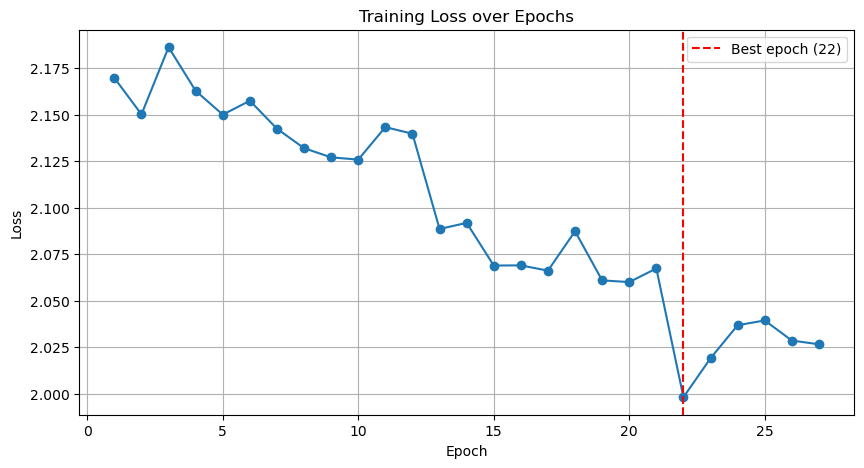

Best loss: 1.998187 at epoch 22
Final loss: 2.026620
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 68. Best loss was at epoch 63


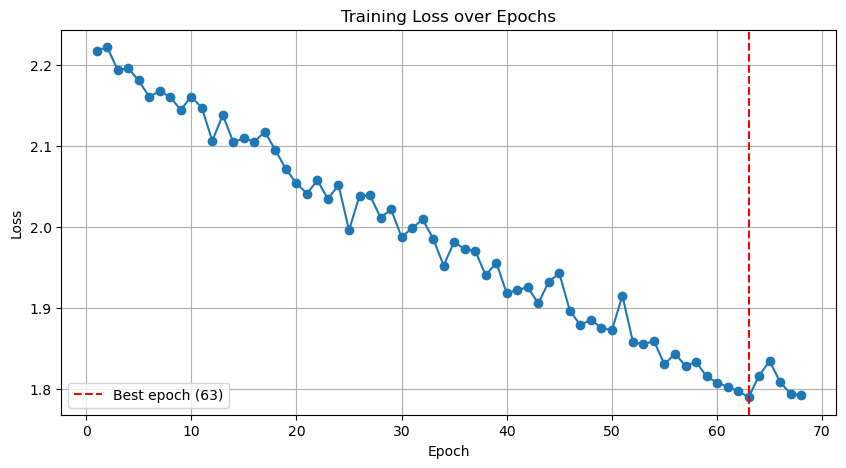

Best loss: 1.789982 at epoch 63
Final loss: 1.792517
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 111. Best loss was at epoch 106


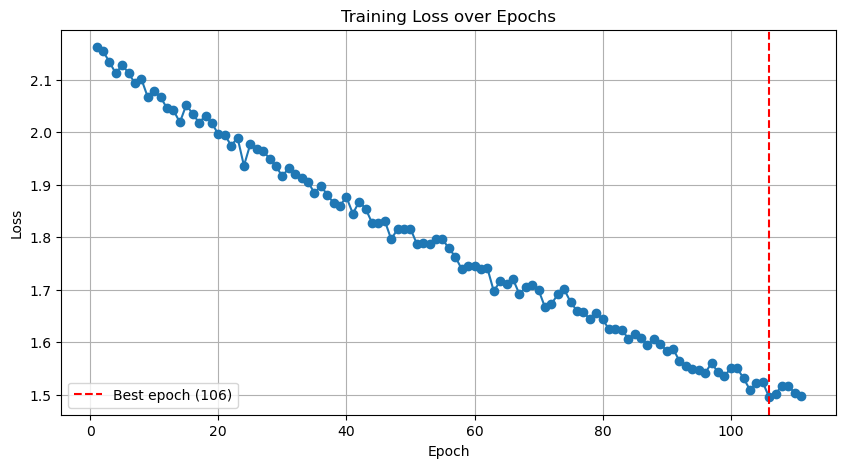

Best loss: 1.495439 at epoch 106
Final loss: 1.497180
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 131. Best loss was at epoch 126


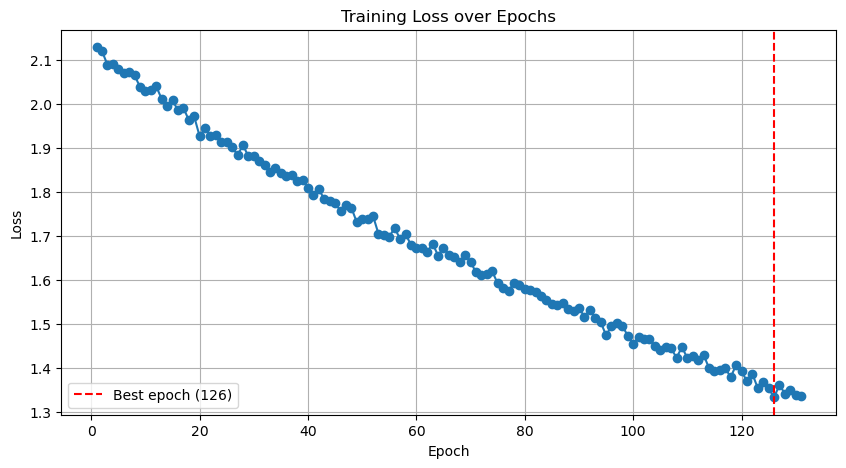

Best loss: 1.333910 at epoch 126
Final loss: 1.337788
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 181. Best loss was at epoch 176


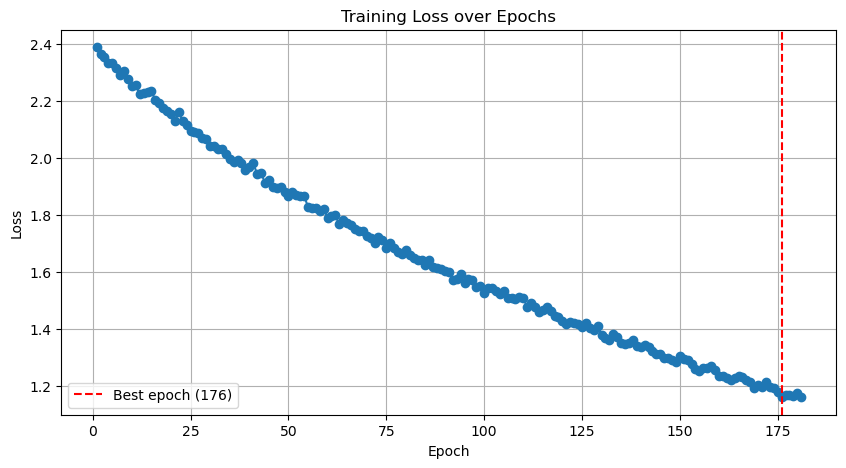

Best loss: 1.160308 at epoch 176
Final loss: 1.162290
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 235. Best loss was at epoch 230


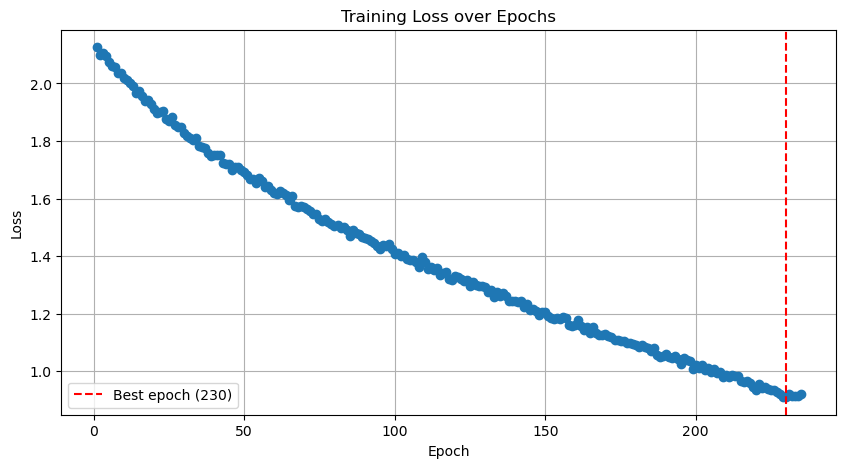

Best loss: 0.910206 at epoch 230
Final loss: 0.920907
{'away_goals_train_accuracy': 0.6753299916457811, 'away_goals_train_precision': 0.5355378359204488, 'away_goals_valid_accuracy': 0.2882205513784461, 'away_goals_valid_precision': 0.141973828690157, 'away_goals_test_accuracy': 0.29699248120300753, 'away_goals_test_precision': 0.1514059487963804, 'away_goals_train_lte_0_accuracy': 0.8333333333333334, 'away_goals_train_lte_0_accuracy_std': 0.12529323147844004, 'away_goals_train_lte_0_precision': 0.7496602443098704, 'away_goals_train_lte_0_precision_std': 0.17869362951426748, 'away_goals_train_eq_1_accuracy': 0.839891395154553, 'away_goals_train_eq_1_accuracy_std': 0.08429046675746504, 'away_goals_train_eq_1_precision': 0.771158957786356, 'away_goals_train_eq_1_precision_std': 0.0397658420478922, 'away_goals_train_eq_2_accuracy': 0.8649289891395154, 'away_goals_train_eq_2_accuracy_std': 0.059605871118224504, 'away_goals_train_eq_2_precision': 0.7030218671872904, 'away_goals_train_eq_2_p

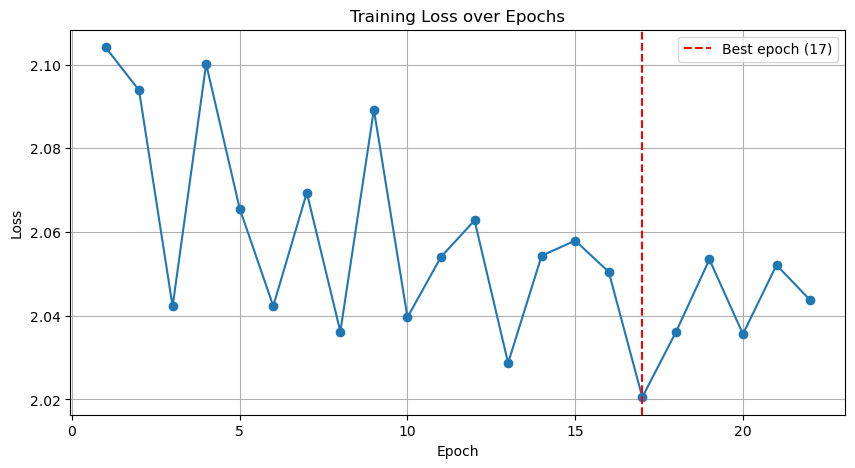

Best loss: 2.020534 at epoch 17
Final loss: 2.043778
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 6. Best loss was at epoch 1


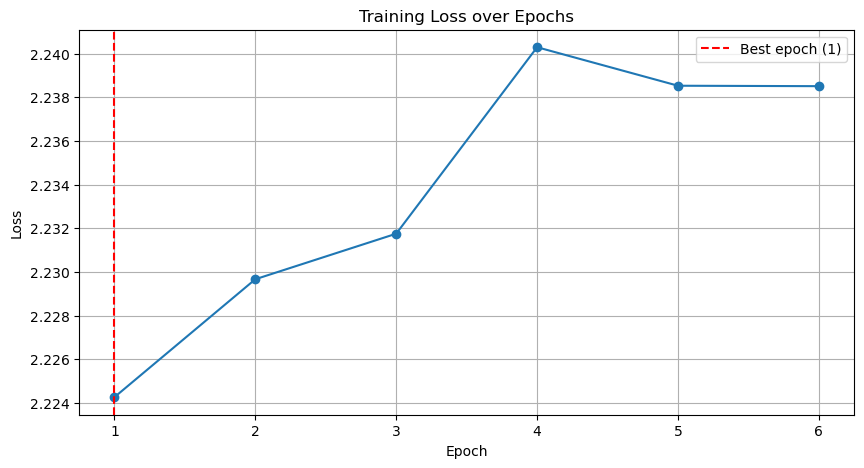

Best loss: 2.224259 at epoch 1
Final loss: 2.238511
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 10. Best loss was at epoch 5


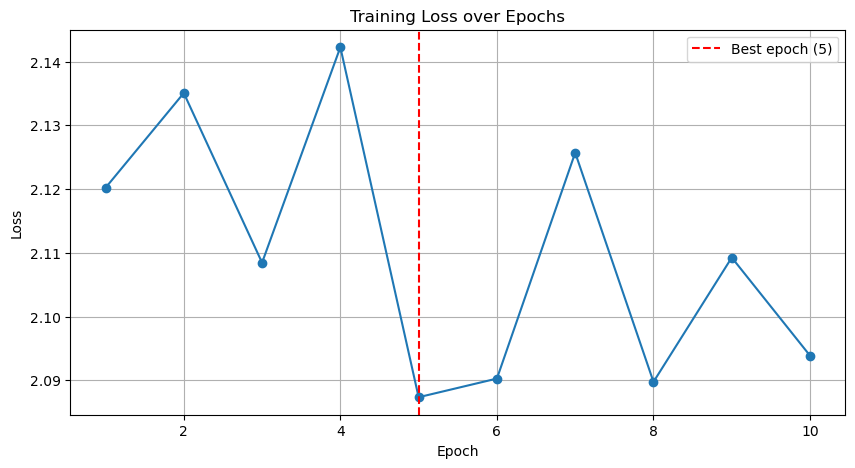

Best loss: 2.087341 at epoch 5
Final loss: 2.093859
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 78. Best loss was at epoch 73


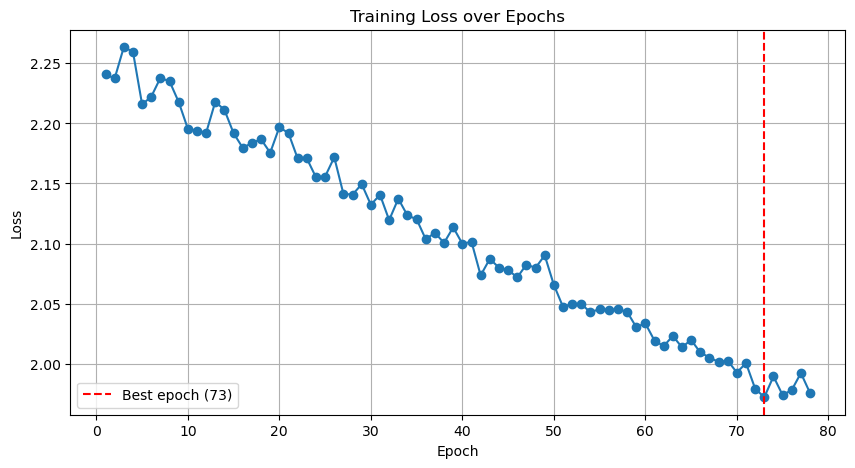

Best loss: 1.972071 at epoch 73
Final loss: 1.975554
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 63. Best loss was at epoch 58


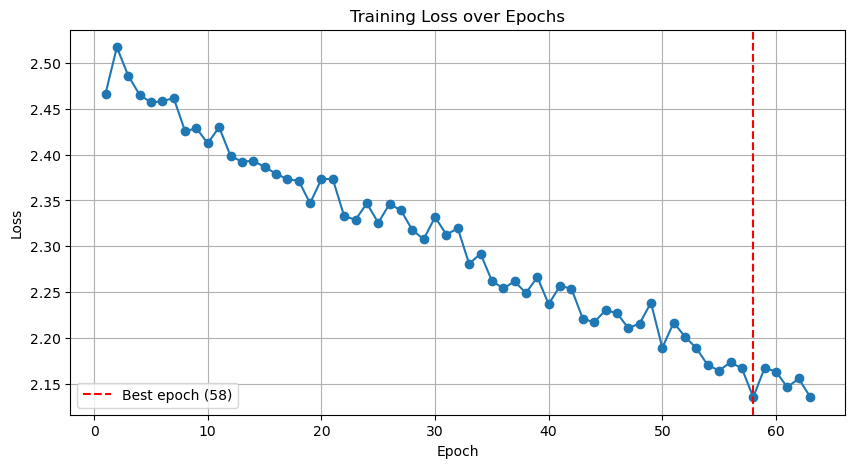

Best loss: 2.135073 at epoch 58
Final loss: 2.135666
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 32. Best loss was at epoch 27


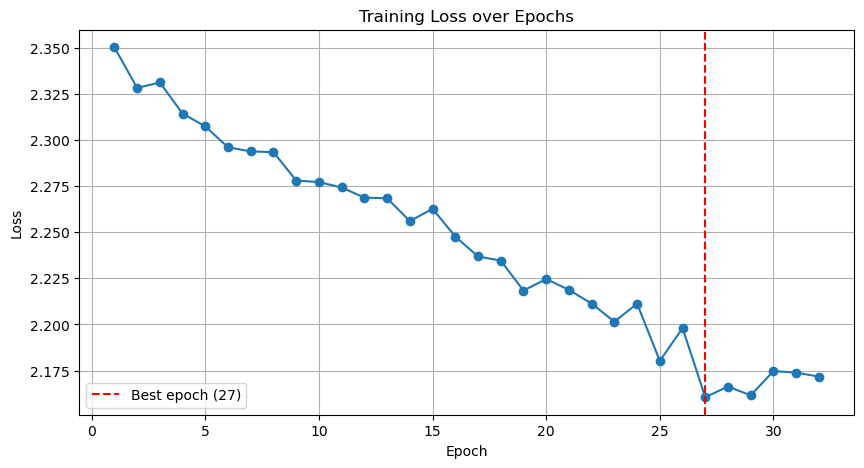

Best loss: 2.160580 at epoch 27
Final loss: 2.171744
{'away_goals_train_accuracy': 0.23883040935672514, 'away_goals_train_precision': 0.1706228780208988, 'away_goals_valid_accuracy': 0.1794486215538847, 'away_goals_valid_precision': 0.10868954344531354, 'away_goals_test_accuracy': 0.21052631578947367, 'away_goals_test_precision': 0.04579174166803033, 'away_goals_train_lte_0_accuracy': 0.6045196324143692, 'away_goals_train_lte_0_accuracy_std': 0.08931976086075549, 'away_goals_train_lte_0_precision': 0.4319008846889436, 'away_goals_train_lte_0_precision_std': 0.14617096122540876, 'away_goals_train_eq_1_accuracy': 0.6589724310776942, 'away_goals_train_eq_1_accuracy_std': 0.036635192071730015, 'away_goals_train_eq_1_precision': 0.4060457643646057, 'away_goals_train_eq_1_precision_std': 0.25088794805915116, 'away_goals_train_eq_2_accuracy': 0.7282623224728487, 'away_goals_train_eq_2_accuracy_std': 0.05638708857533466, 'away_goals_train_eq_2_precision': 0.30600626790140895, 'away_goals_train

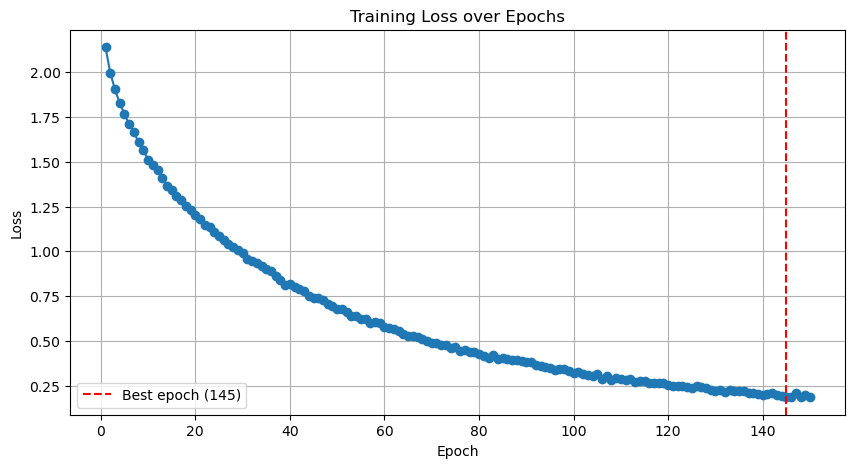

Best loss: 0.185627 at epoch 145
Final loss: 0.186806
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 158. Best loss was at epoch 153


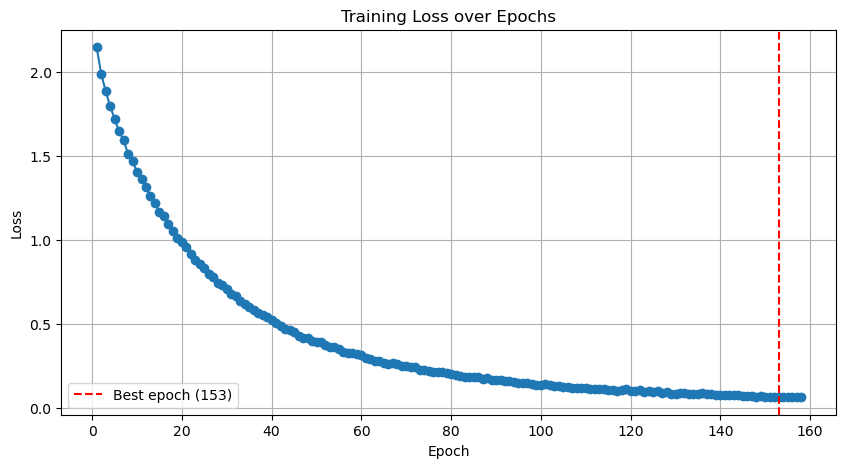

Best loss: 0.065142 at epoch 153
Final loss: 0.065562
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 157. Best loss was at epoch 152


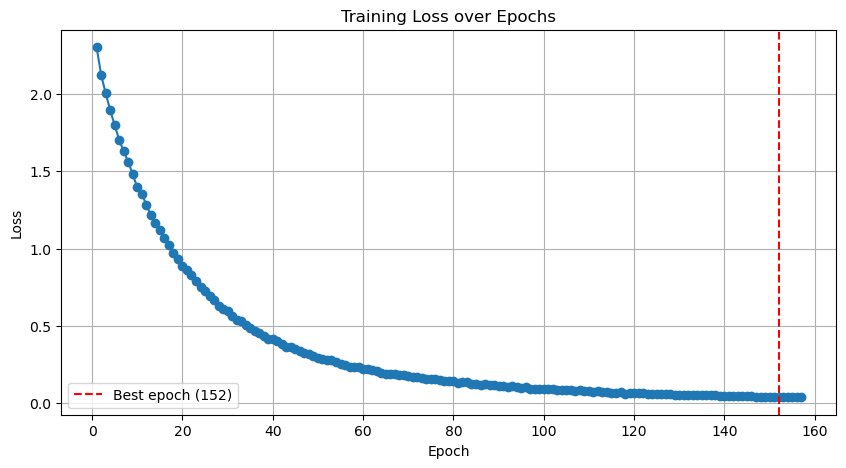

Best loss: 0.039322 at epoch 152
Final loss: 0.039644
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 172. Best loss was at epoch 167


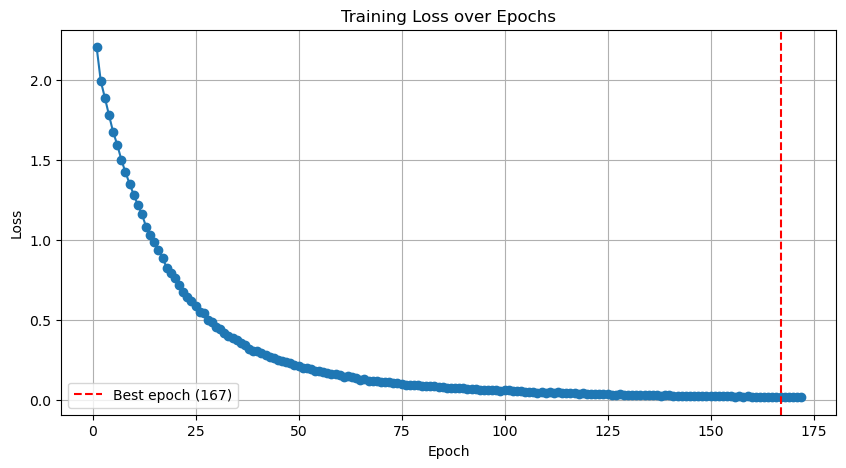

Best loss: 0.018112 at epoch 167
Final loss: 0.019519
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 137. Best loss was at epoch 132


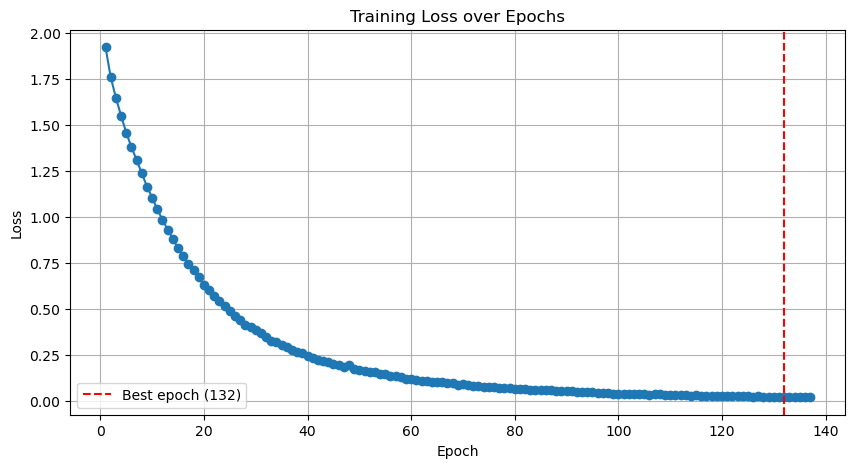

Best loss: 0.021636 at epoch 132
Final loss: 0.022332
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 117. Best loss was at epoch 112


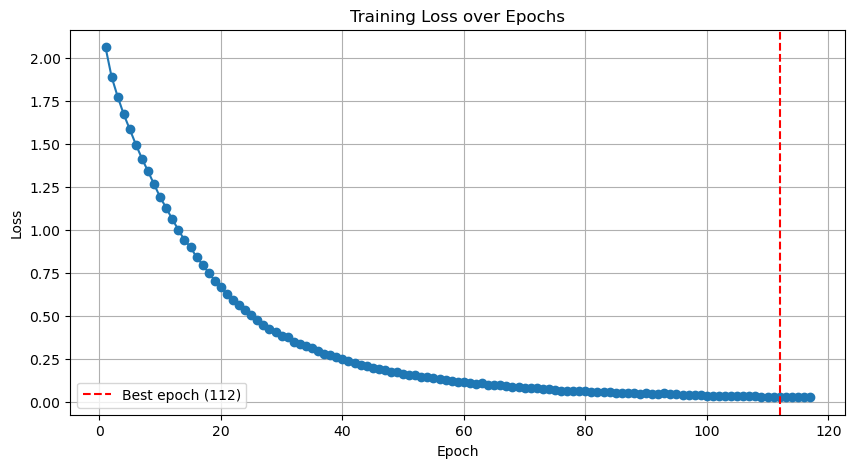

Best loss: 0.026490 at epoch 112
Final loss: 0.026540
{'away_goals_train_accuracy': 1.0, 'away_goals_train_precision': 1.0, 'away_goals_valid_accuracy': 0.2746867167919799, 'away_goals_valid_precision': 0.14069877775167605, 'away_goals_test_accuracy': 0.2819548872180451, 'away_goals_test_precision': 0.1403083794898185, 'away_goals_train_lte_0_accuracy': 1.0, 'away_goals_train_lte_0_accuracy_std': 0.0, 'away_goals_train_lte_0_precision': 1.0, 'away_goals_train_lte_0_precision_std': 0.0, 'away_goals_train_eq_1_accuracy': 1.0, 'away_goals_train_eq_1_accuracy_std': 0.0, 'away_goals_train_eq_1_precision': 1.0, 'away_goals_train_eq_1_precision_std': 0.0, 'away_goals_train_eq_2_accuracy': 1.0, 'away_goals_train_eq_2_accuracy_std': 0.0, 'away_goals_train_eq_2_precision': 1.0, 'away_goals_train_eq_2_precision_std': 0.0, 'away_goals_train_eq_3_accuracy': 1.0, 'away_goals_train_eq_3_accuracy_std': 0.0, 'away_goals_train_eq_3_precision': 1.0, 'away_goals_train_eq_3_precision_std': 0.0, 'away_goals

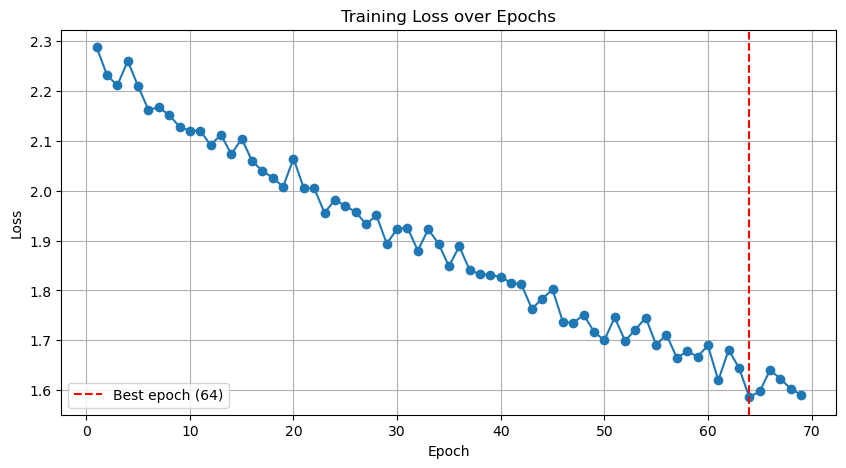

Best loss: 1.585753 at epoch 64
Final loss: 1.590595
Training fold 2/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 101. Best loss was at epoch 96


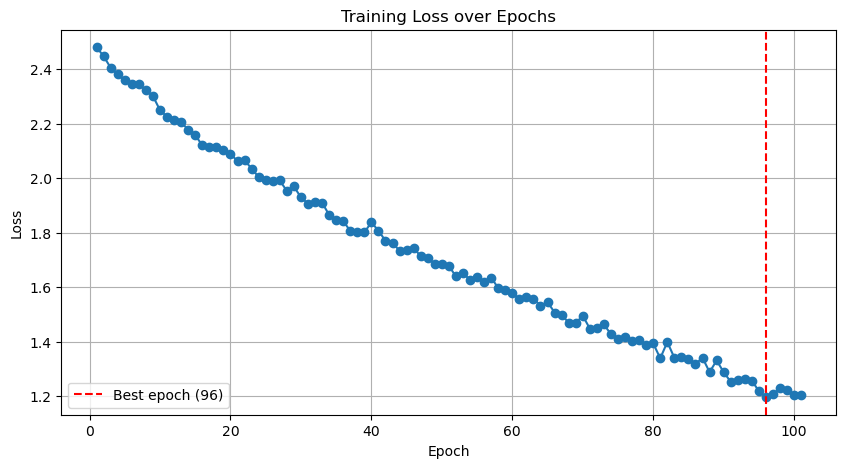

Best loss: 1.196635 at epoch 96
Final loss: 1.205452
Training fold 3/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 131. Best loss was at epoch 126


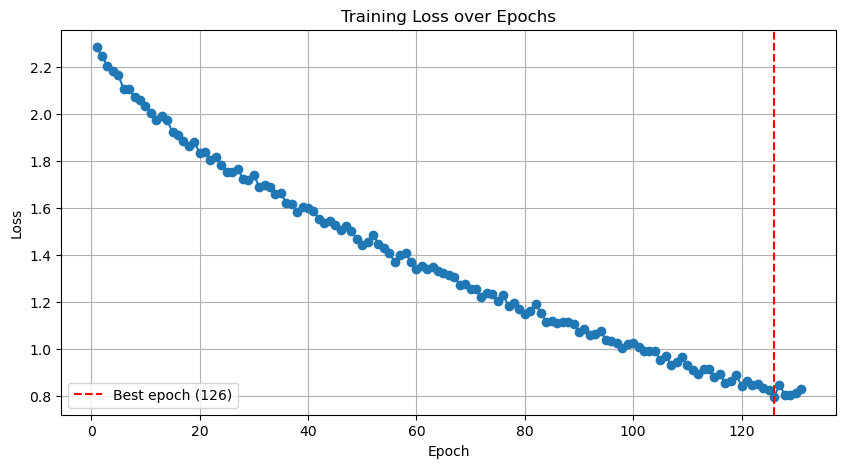

Best loss: 0.796025 at epoch 126
Final loss: 0.829778
Training fold 4/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 168. Best loss was at epoch 163


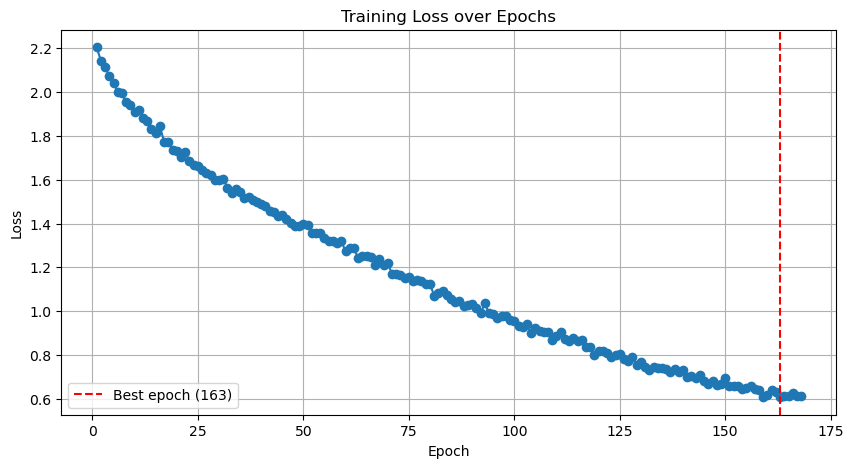

Best loss: 0.607603 at epoch 163
Final loss: 0.614865
Training fold 5/5 with params: {'model_params.hidden_layers': (64, 32, 32), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 92. Best loss was at epoch 87


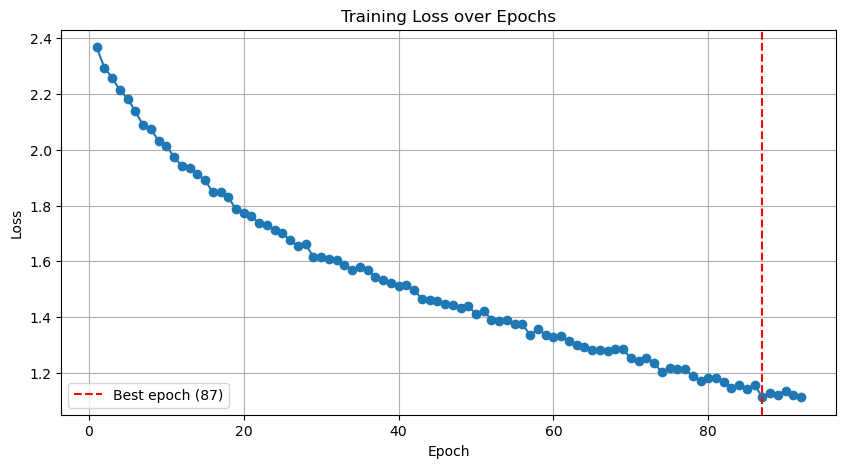

Best loss: 1.113155 at epoch 87
Final loss: 1.113615
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 162. Best loss was at epoch 157


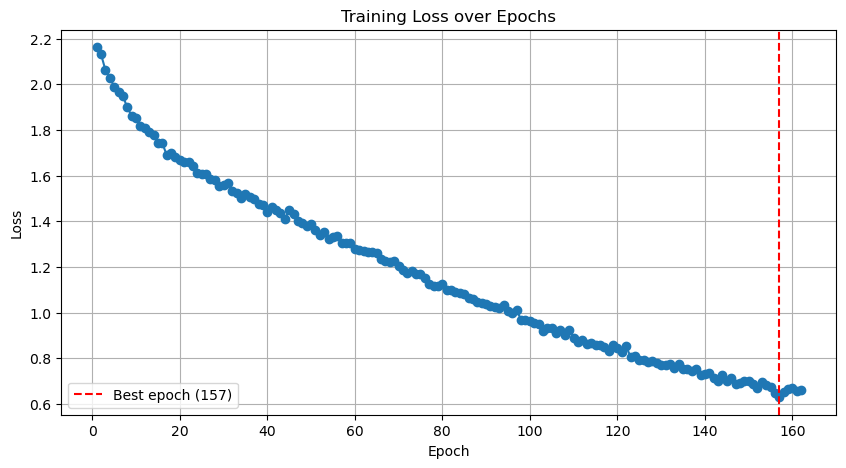

Best loss: 0.629306 at epoch 157
Final loss: 0.661099
{'away_goals_train_accuracy': 0.8456975772765245, 'away_goals_train_precision': 0.4071159021441953, 'away_goals_valid_accuracy': 0.29223057644110273, 'away_goals_valid_precision': 0.13092877639047965, 'away_goals_test_accuracy': 0.31203007518796994, 'away_goals_test_precision': 0.15664473541354526, 'away_goals_train_lte_0_accuracy': 0.9166332497911445, 'away_goals_train_lte_0_accuracy_std': 0.08567179731900362, 'away_goals_train_lte_0_precision': 0.8376877845720203, 'away_goals_train_lte_0_precision_std': 0.17223941704124932, 'away_goals_train_eq_1_accuracy': 0.939715956558062, 'away_goals_train_eq_1_accuracy_std': 0.0634085895458526, 'away_goals_train_eq_1_precision': 0.9451678623319175, 'away_goals_train_eq_1_precision_std': 0.03474983925234757, 'away_goals_train_eq_2_accuracy': 0.9424561403508772, 'away_goals_train_eq_2_accuracy_std': 0.03603330236606165, 'away_goals_train_eq_2_precision': 0.8427619594624012, 'away_goals_train_eq

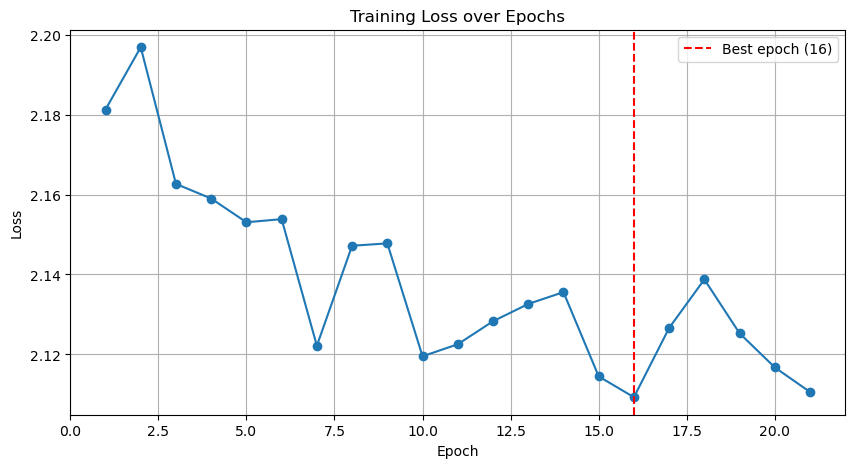

Best loss: 2.109292 at epoch 16
Final loss: 2.110594
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 86. Best loss was at epoch 81


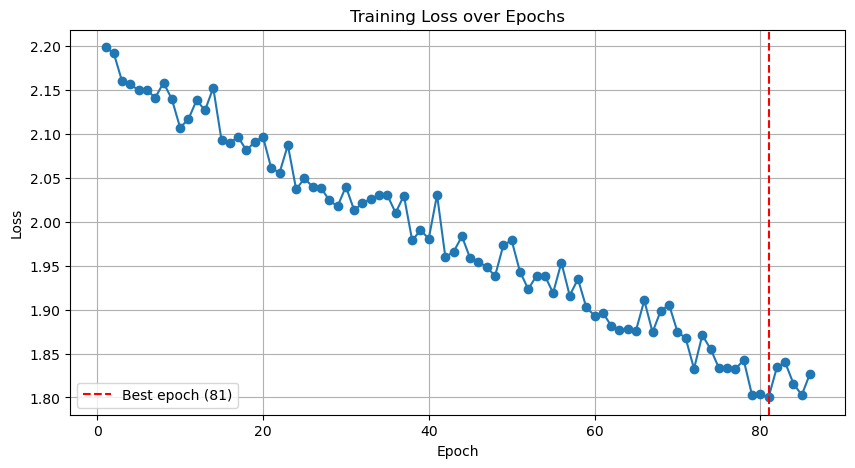

Best loss: 1.800222 at epoch 81
Final loss: 1.827132
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 14. Best loss was at epoch 9


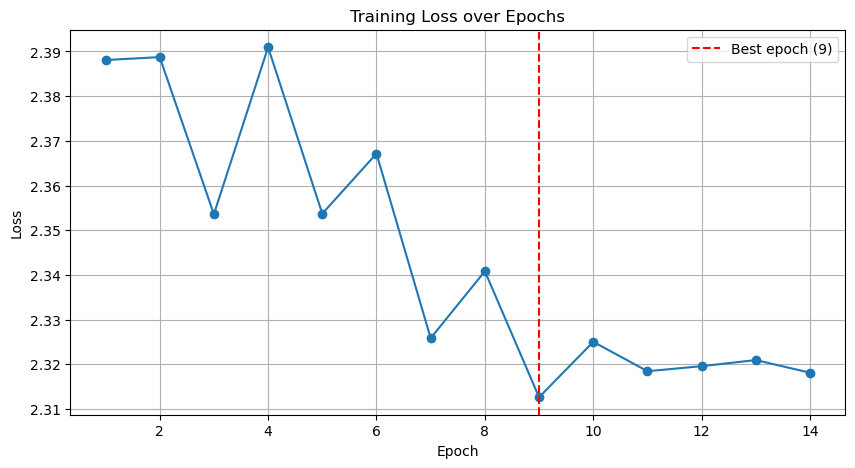

Best loss: 2.312642 at epoch 9
Final loss: 2.318125
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 176. Best loss was at epoch 171


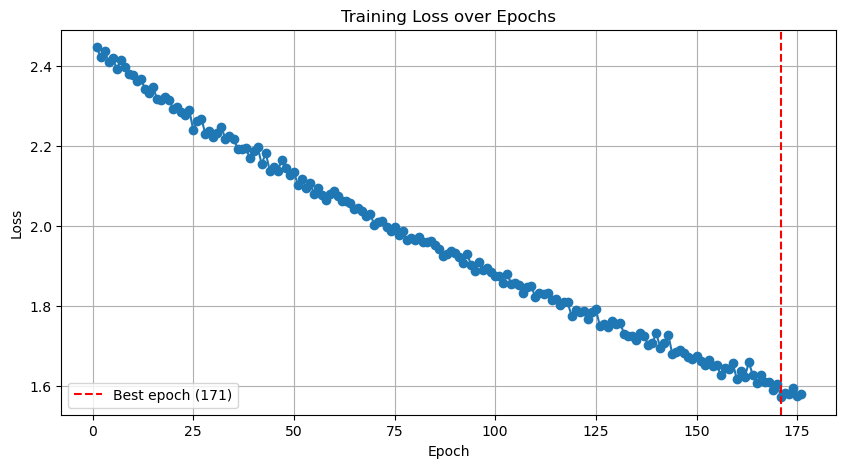

Best loss: 1.572439 at epoch 171
Final loss: 1.580777
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.5, 'learning_rate': 1e-05, 'batch_size': 128, 'epochs': 1000, 'l2_reg': 0}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 46. Best loss was at epoch 41


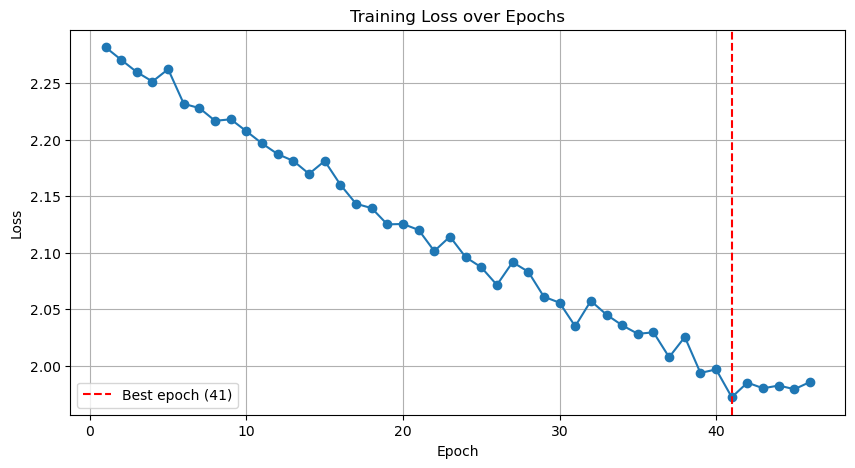

Best loss: 1.971975 at epoch 41
Final loss: 1.985483
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 152. Best loss was at epoch 147


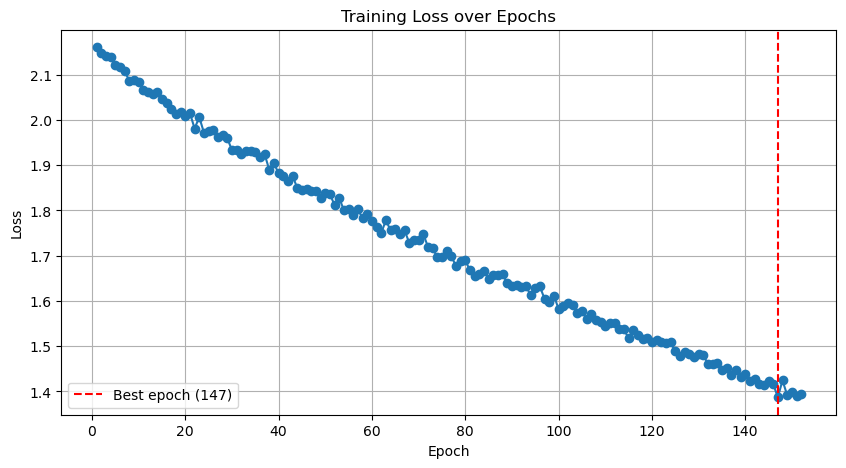

Best loss: 1.387125 at epoch 147
Final loss: 1.394283
{'away_goals_train_accuracy': 0.4023558897243108, 'away_goals_train_precision': 0.3602775999455669, 'away_goals_valid_accuracy': 0.20250626566416038, 'away_goals_valid_precision': 0.11918515267658045, 'away_goals_test_accuracy': 0.2706766917293233, 'away_goals_test_precision': 0.13242592842876663, 'away_goals_train_lte_0_accuracy': 0.7176775271512114, 'away_goals_train_lte_0_accuracy_std': 0.1366395118638706, 'away_goals_train_lte_0_precision': 0.5939249341321675, 'away_goals_train_lte_0_precision_std': 0.19950423520489802, 'away_goals_train_eq_1_accuracy': 0.7319465329991646, 'away_goals_train_eq_1_accuracy_std': 0.081781438367633, 'away_goals_train_eq_1_precision': 0.5716179747512097, 'away_goals_train_eq_1_precision_std': 0.18531247867620895, 'away_goals_train_eq_2_accuracy': 0.8075438596491228, 'away_goals_train_eq_2_accuracy_std': 0.040287501406523, 'away_goals_train_eq_2_precision': 0.5607027247474372, 'away_goals_train_eq_2_p

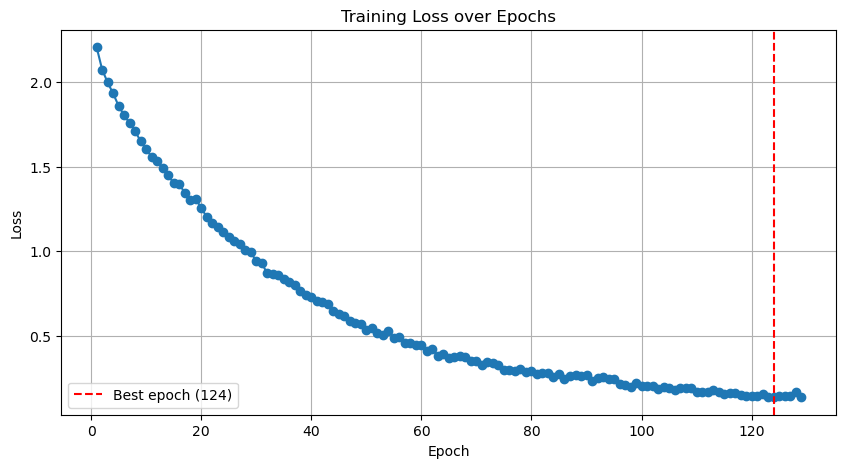

Best loss: 0.137878 at epoch 124
Final loss: 0.140618
Training fold 2/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 101. Best loss was at epoch 96


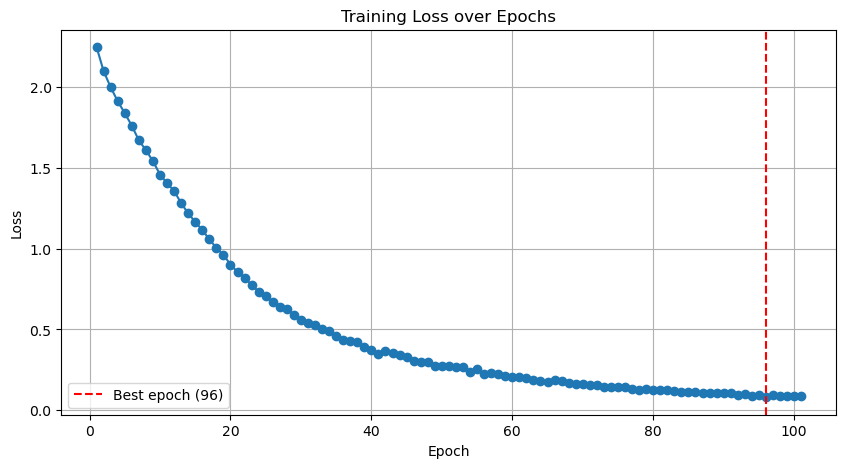

Best loss: 0.080954 at epoch 96
Final loss: 0.088075
Training fold 3/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 110. Best loss was at epoch 105


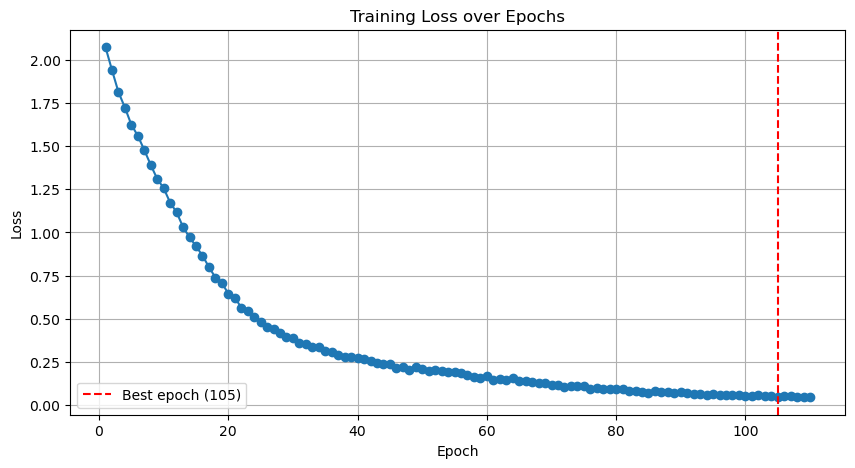

Best loss: 0.045568 at epoch 105
Final loss: 0.049353
Training fold 4/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 72. Best loss was at epoch 67


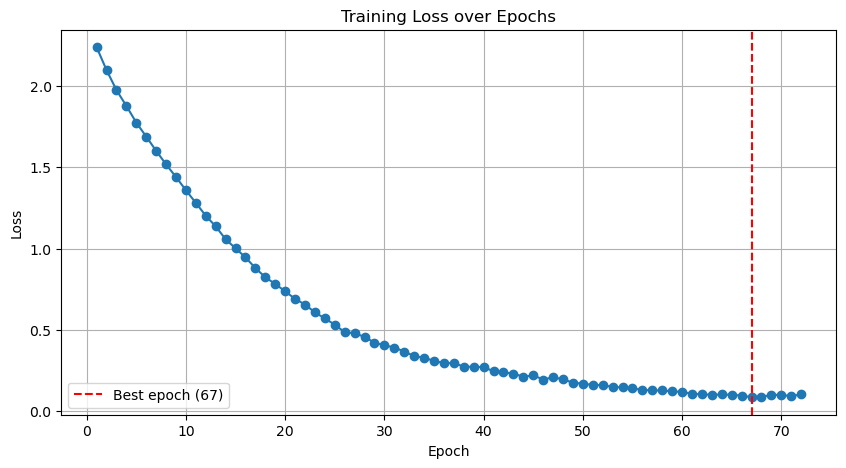

Best loss: 0.086460 at epoch 67
Final loss: 0.105575
Training fold 5/5 with params: {'model_params.hidden_layers': (128, 128, 64, 64), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0.1, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 1000, 'l2_reg': 0.1}
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 58. Best loss was at epoch 53


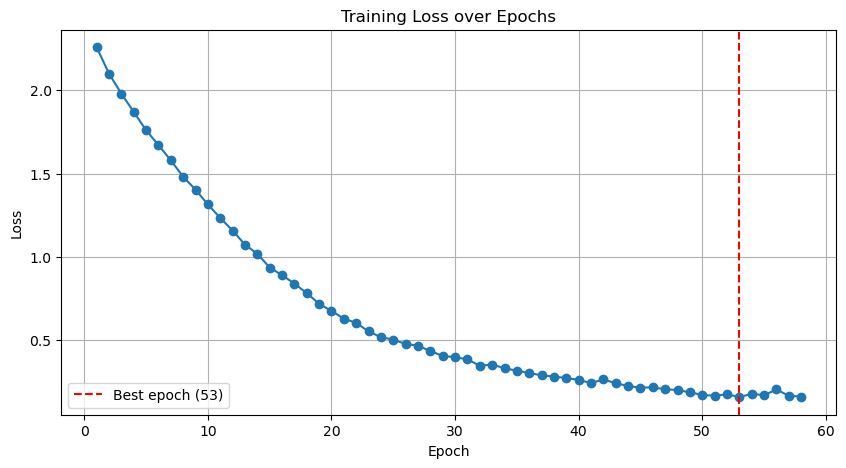

Best loss: 0.157315 at epoch 53
Final loss: 0.161474
[TorchWrapper] Using device: mps
Early stopping triggered at epoch 79. Best loss was at epoch 74


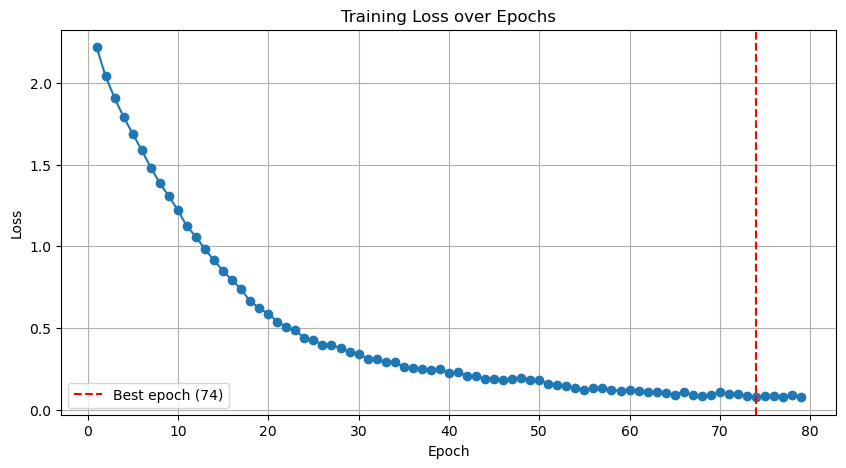

Best loss: 0.076043 at epoch 74
Final loss: 0.079346
{'away_goals_train_accuracy': 0.9955054302422723, 'away_goals_train_precision': 0.7910222486853926, 'away_goals_valid_accuracy': 0.2706766917293233, 'away_goals_valid_precision': 0.13302797780502176, 'away_goals_test_accuracy': 0.2744360902255639, 'away_goals_test_precision': 0.1436775492465565, 'away_goals_train_lte_0_accuracy': 0.9991311612364244, 'away_goals_train_lte_0_accuracy_std': 0.0012959545149316826, 'away_goals_train_lte_0_precision': 0.9972405110668776, 'away_goals_train_lte_0_precision_std': 0.004104730647524742, 'away_goals_train_eq_1_accuracy': 0.9983792815371763, 'away_goals_train_eq_1_accuracy_std': 0.0012431796315948778, 'away_goals_train_eq_1_precision': 0.995095910441316, 'away_goals_train_eq_1_precision_std': 0.003737504284157506, 'away_goals_train_eq_2_accuracy': 0.9991228070175439, 'away_goals_train_eq_2_accuracy_std': 0.000937758743552384, 'away_goals_train_eq_2_precision': 0.9964031017776221, 'away_goals_trai

In [7]:

run_multiclass_distribution_experiment(
    feature_df=feature_df,
    target_df=target_df,
    target_ranges=TRAINGING_CONFIG['target_ranges'],
    model_wrapper_class=lambda **params: TorchWrapper(
        model_class=MLPWithDropoutBN,
        model_params={k.replace('model_params.', ''): v for k, v in params.items() if k.startswith('model_params.')},
        learning_rate=params.get('learning_rate', 0.001),
        batch_size=params.get('batch_size', 64),
        epochs=params.get('epochs', 20)
    ),
    model_param_grid=param_grid,
    test_size=TRAINGING_CONFIG['test_size'],
    k=5,
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    key_columns=TRAINGING_CONFIG['key_columns'],
    uri=f'{REPO_PATH}/mlflow',
    model_name='MLPwithDropoutBN',
    save_model_path=TRAINGING_CONFIG['save_model_path'],
    max_param_sets=10
)

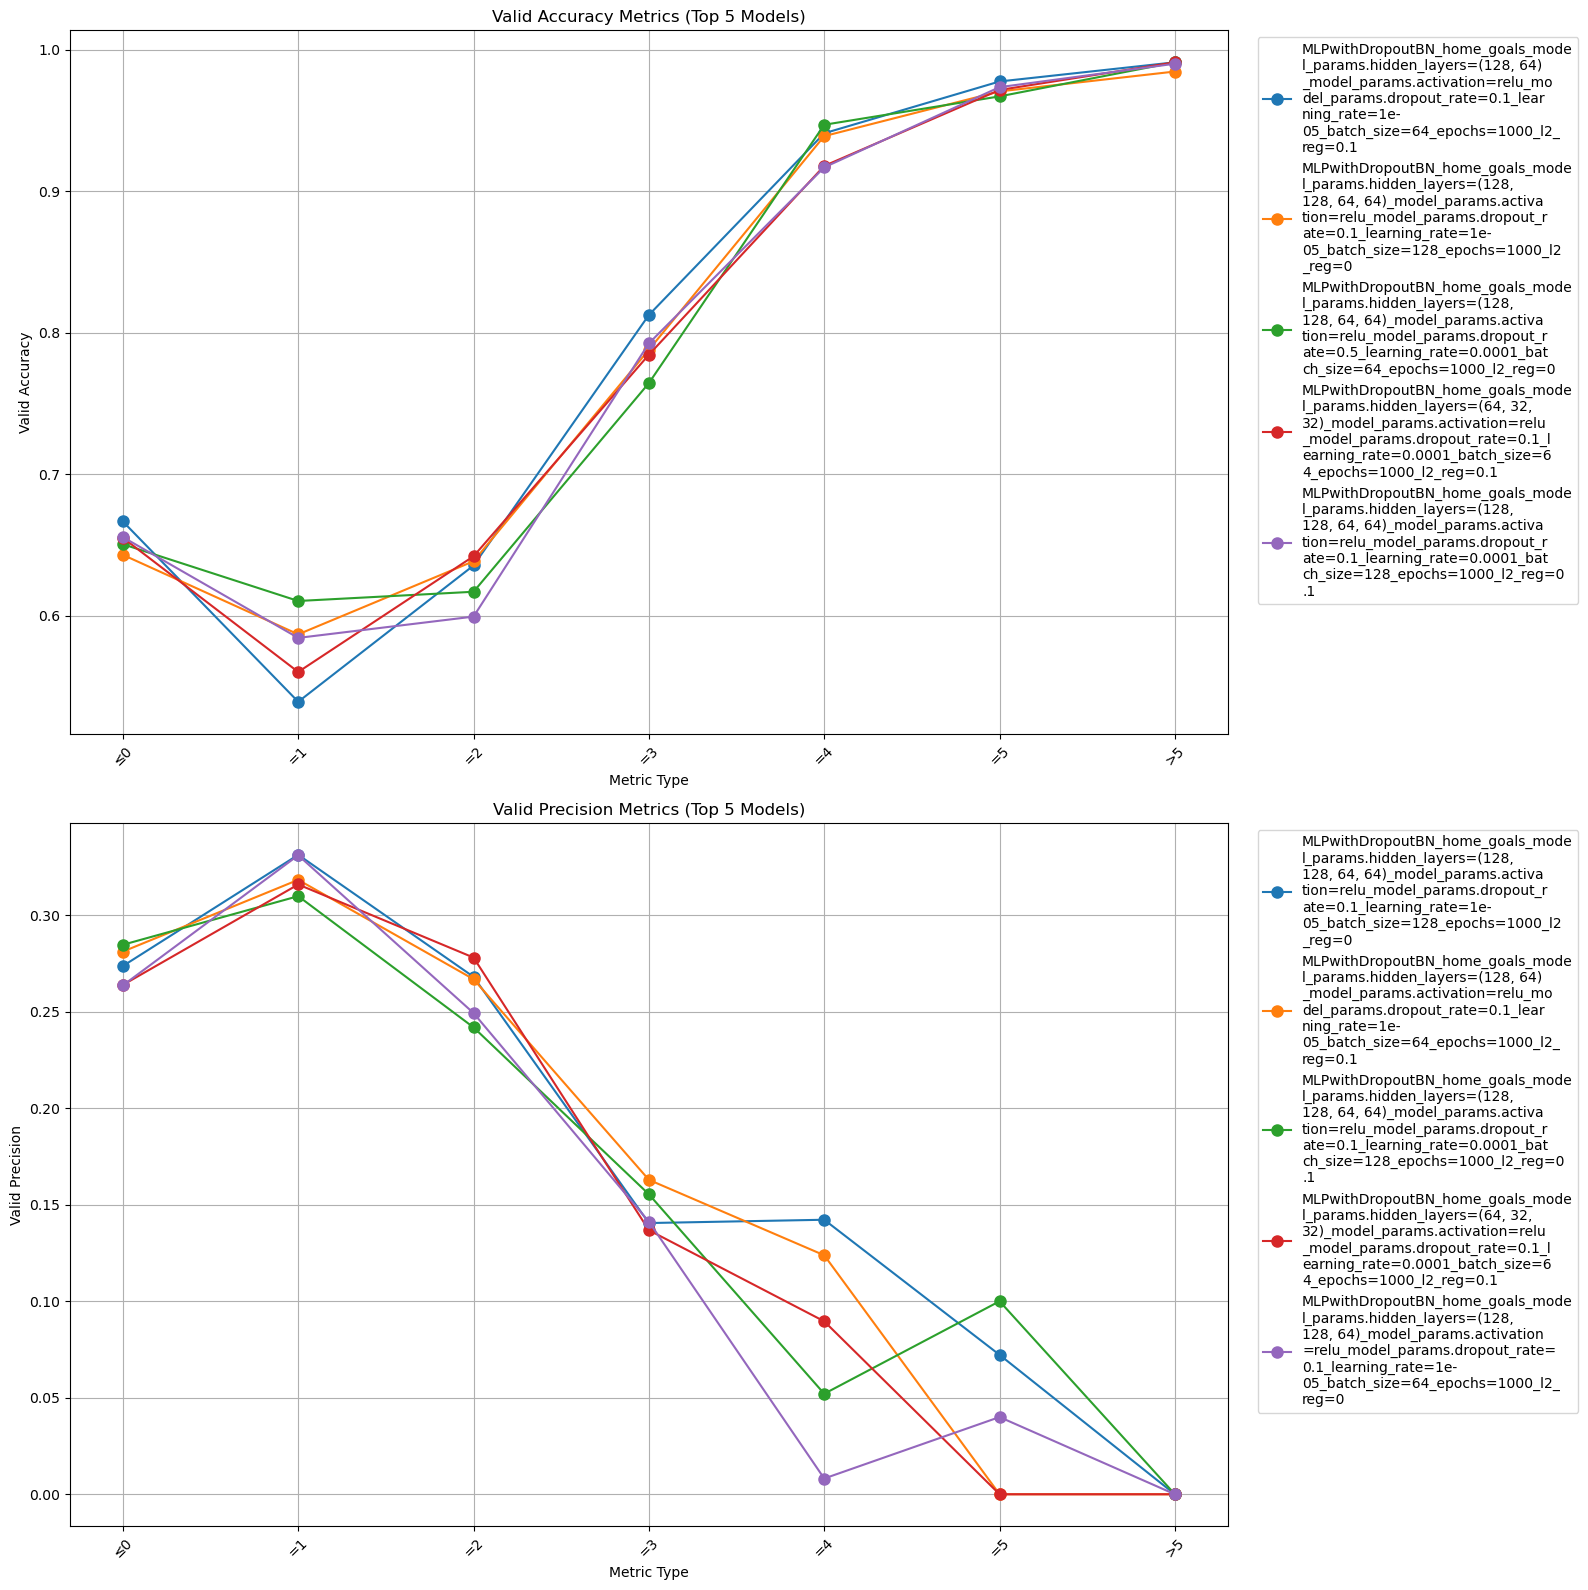

In [8]:
plot_metrics_for_target_and_model(
    experiment_name=TRAINGING_CONFIG['experiment_name'],
    target_col="home_goals",
    model_name="MLPwithDropoutBN",
    tracking_uri=f"{REPO_PATH}/mlflow"
)

In [9]:
plot_run_metrics_by_split(experiment_name=TRAINGING_CONFIG['experiment_name'],
                         run_name="MLPwithDropoutBN_away_goals_model_params.hidden_layers=(256, 128, 128, 64)_model_params.activation=relu_model_params.dropout_rate=0.1_learning_rate=1e-05_batch_size=64_epochs=2000",
                         target_col="away_goals",
                         tracking_uri=f"{REPO_PATH}/mlflow")

No run found with name 'MLPwithDropoutBN_away_goals_model_params.hidden_layers=(256, 128, 128, 64)_model_params.activation=relu_model_params.dropout_rate=0.1_learning_rate=1e-05_batch_size=64_epochs=2000'.


In [10]:
plot_run_metrics_side_by_side(experiment_name=TRAINGING_CONFIG['experiment_name'],
                              model_name="MLPwithDropoutBN",
                              model_param={'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 0.00001, 'batch_size': 64, 'epochs': 5000},
                              tracking_uri=f"{REPO_PATH}/mlflow",
                              metric_type="precision")

Searching for runs with filter: params.model_name = 'MLPwithDropoutBN' and params.model_params.hidden_layers= '(512, 256, 256, 128, 128)' and params.model_params.activation= 'relu' and params.model_params.dropout_rate= '0' and params.learning_rate= '1e-05' and params.batch_size= '64' and params.epochs= '5000'
No runs found with model_name 'MLPwithDropoutBN' and params {'model_params.hidden_layers': (512, 256, 256, 128, 128), 'model_params.activation': 'relu', 'model_params.dropout_rate': 0, 'learning_rate': 1e-05, 'batch_size': 64, 'epochs': 5000}.
